# **📊 Pr. 5**

---


**Title:** House Price Prediction

**Duration:** 6 Hours

---


## **📑 Project Overview**

You are working as a Junior Data Scientist at a PropTech startup similar to NoBroker or MagicBricks. The product team wants an automated house price estimator to help buyers and sellers in the Indian market benchmark property values.

You are given the Ames Housing Dataset (a popular regression benchmark from Kaggle / UCI), which contains 79 features describing almost every aspect of residential homes. Your task is to build a complete end-to-end Supervised Learning pipeline that predicts the sale price of a house (regression task).

---


## **📚 Download and Import Modules**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    OrdinalEncoder,
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import joblib

---


## **🧠 Step 1: Problem Framing & Theory Notes**

### 1. What is Regression? How is it different from Classification? Give 2 real-world Indian examples (e.g., predicting EMI at HDFC, predicting crop yield in Maharashtra).

**Regression** is a machine learning technique used to predict continuous, numerical outcomes, whereas classification categorises data into distinct, discrete labels. For example, predicting the exact rupee value of a car loan EMI at HDFC Bank is a regression task, while determining if a farmer's crop in Maharashtra will succeed or fail (Yes/No) is a classification task.

### 2. What is the difference between Simple Linear Regression, Multiple Linear Regression, and Regularised Regression (Ridge / Lasso)?

| Regression Type     | Predictors      | Core Mechanism                             | Key Feature                                                     |
| :------------------ | :-------------- | :----------------------------------------- | :-------------------------------------------------------------- |
| **Simple Linear**   | **One**         | Fits a straight line ($y = mx + c$)        | Models a single direct relationship                             |
| **Multiple Linear** | **Two or more** | Fits a multi-dimensional hyperplane        | Captures multiple simultaneous influences                       |
| **Regularised**     | **Two or more** | Adds a penalty term to shrink coefficients | Prevents overfitting (Lasso drops features, Ridge shrinks them) |

### 3. Explain Overfitting and Underfitting. How does regularisation (L1/L2) help prevent them?

- **Overfitting** happens when a model learns training data noise, performing poorly on new data; **underfitting** occurs when it is too simple to capture the underlying trend.
- **L1 (Lasso) and L2 (Ridge) regularisation** add a penalty to the loss function based on the size of the coefficients.
- This penalty discourages the model from becoming overly complex, effectively preventing **overfitting** by shrinking or eliminating unhelpful features.

### 4. Define RMSE, MAE, and R². When would you prefer RMSE over MAE?

- **MAE** measures the average error magnitude, **RMSE** gives higher weight to larger errors, and **R²** shows the percentage of variance explained by the model.
- Prefer **RMSE over MAE** when large errors are exceptionally costly or undesirable.
- Because RMSE squares the errors before averaging, it heavily penalises **extreme outliers**, forcing the model to minimize catastrophic misses.

### 5. What is Cross-Validation (k-Fold)? Why is it preferred over a single train-test split for model evaluation?

- **k-Fold Cross-Validation** splits a dataset into $k$ equal parts, training the model $k$ times while using a different part as the test set each time.
- It is preferred over a single train-test split because it uses the entire dataset for both training and testing, ensuring every data point is evaluated.
- This reduces **selection bias**, delivers a more stable performance estimate, and helps reliably detect **overfitting** across diverse data subsets.

---


## **📂 Step 2: Dataset Loading & Exploratory Data Analysis**

**2.1 Load & Understand the Dataset**

- Load train.csv using pandas. Print .shape, .info(), and .describe().
- Identify:
  1. how many numerical columns
  2. how many categorical columns
  3. how many columns have missing values.
- Plot a histogram and Q-Q plot of the target variable SalePrice. Is it normally distributed? Apply log1p transformation and re-plot.

**2.2 Univariate Analysis**

- Plot histograms for all numerical features. Identify the top 5 most skewed columns.
- Plot countplots for high-impact categorical columns: Neighborhood, BldgType, HouseStyle.

**2.3 Bivariate Analysis**

- Plot a heatmap of the top 15 features most correlated with SalePrice.
- Scatter plots: GrLivArea vs SalePrice, TotalBsmtSF vs SalePrice, GarageArea vs SalePrice.
- Boxplots: OverallQual vs SalePrice, Neighborhood vs SalePrice (which neighborhood is the priciest?).
- Identify and flag any outliers visible in GrLivArea vs SalePrice (hint: two extreme points exist).


> 📌 Key features to focus on: GrLivArea, TotalBsmtSF, OverallQual, GarageArea, YearBuilt, Neighborhood, BldgType, SalePrice


In [2]:
df_train = pd.read_csv("data/train.csv")

key_focus_features = [
    "GrLivArea",
    "TotalBsmtSF",
    "OverallQual",
    "GarageArea",
    "YearBuilt",
    "Neighborhood",
    "BldgType",
    "SalePrice",
]
df_train_key_focus = df_train[key_focus_features]

print("Training Data First 5 Rows:")
print(df_train_key_focus.head())
print("\nTraining Data Shape:", df_train_key_focus.shape)

print("\nTraining Data Info:")
print(df_train_key_focus.info())

print("\nTraining Data Description:")
print(df_train_key_focus.describe())

print("\nTraining Data Missing Values:")
print(df_train_key_focus.isnull().sum())

Training Data First 5 Rows:
   GrLivArea  TotalBsmtSF  OverallQual  GarageArea  YearBuilt Neighborhood  \
0       1710          856            7         548       2003      CollgCr   
1       1262         1262            6         460       1976      Veenker   
2       1786          920            7         608       2001      CollgCr   
3       1717          756            7         642       1915      Crawfor   
4       2198         1145            8         836       2000      NoRidge   

  BldgType  SalePrice  
0     1Fam     208500  
1     1Fam     181500  
2     1Fam     223500  
3     1Fam     140000  
4     1Fam     250000  

Training Data Shape: (1460, 8)

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   GrLivArea     1460 non-null   int64 
 1   TotalBsmtSF   1460 non-null   int64 
 2   OverallQual   1460 non-null

Hist plot for numeric features:


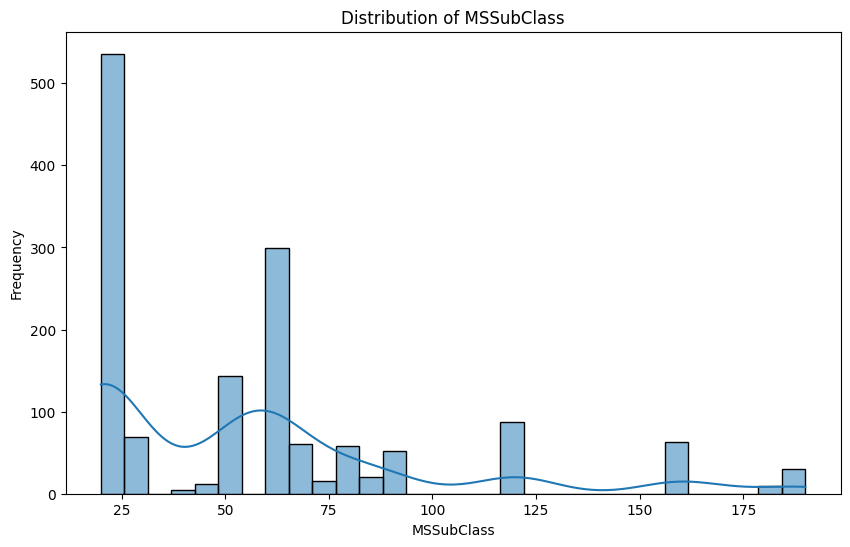

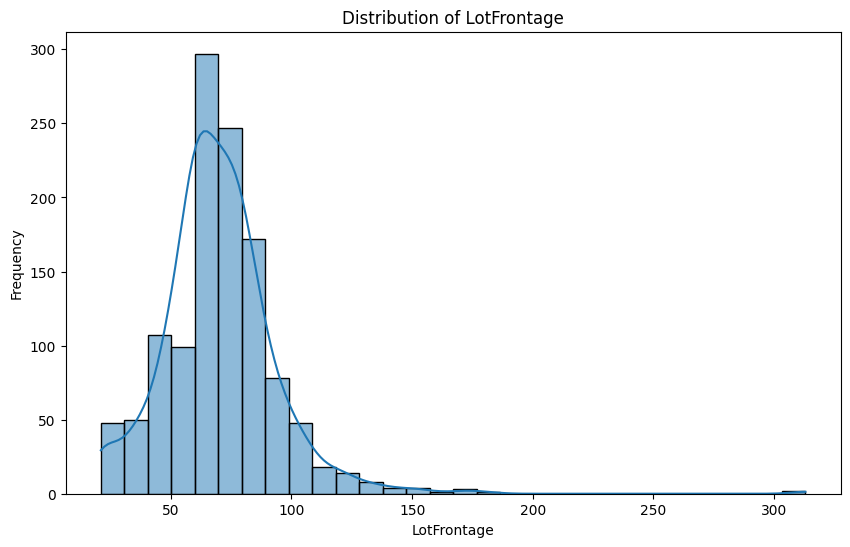

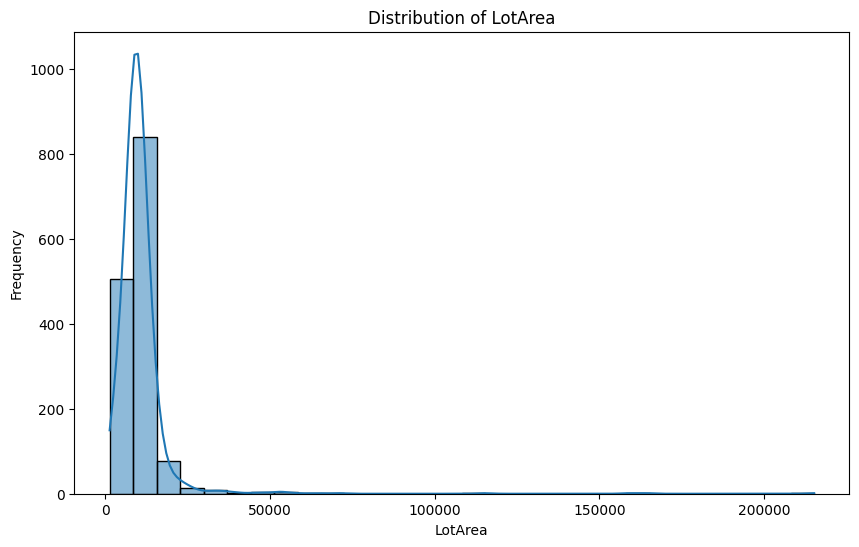

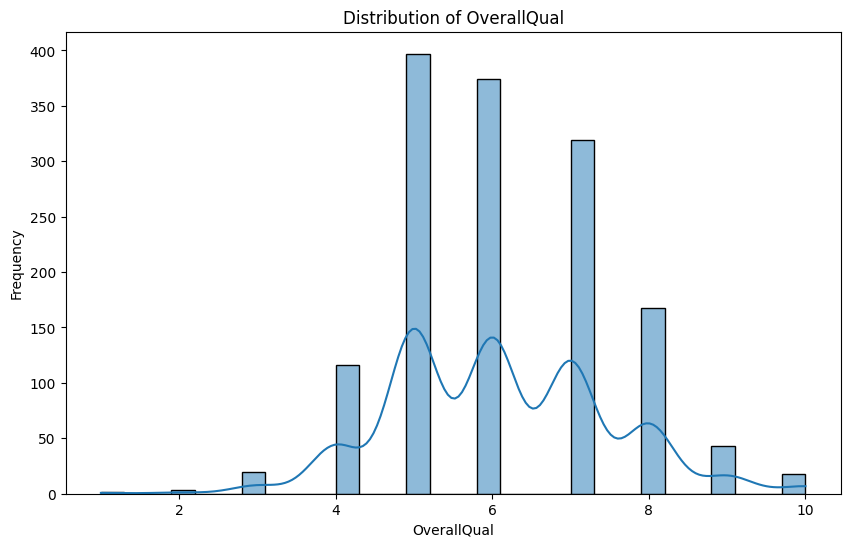

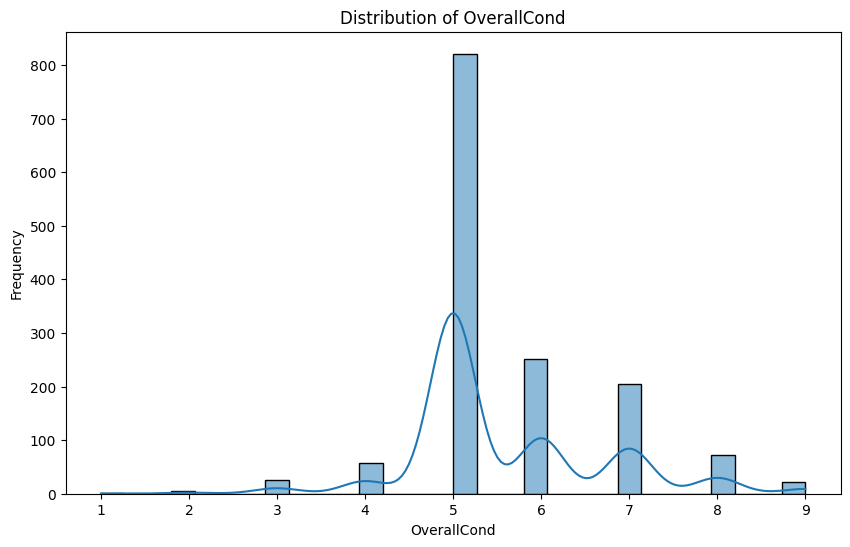

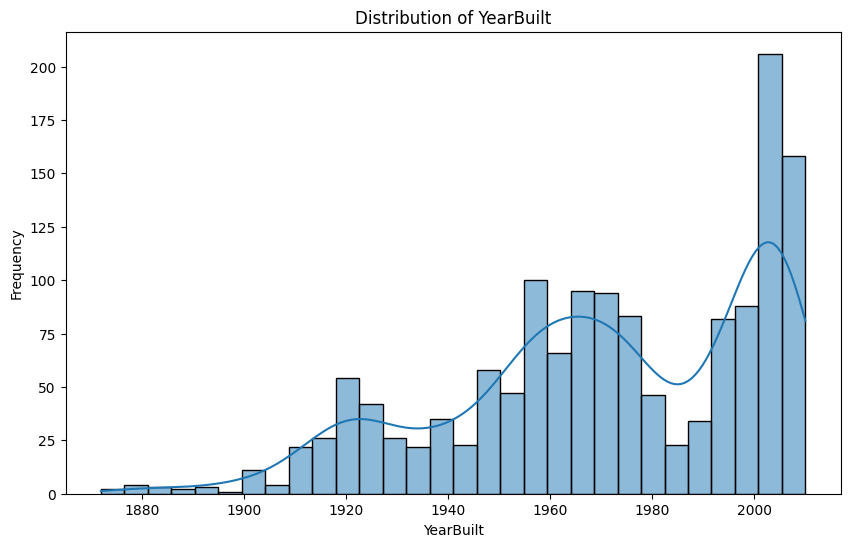

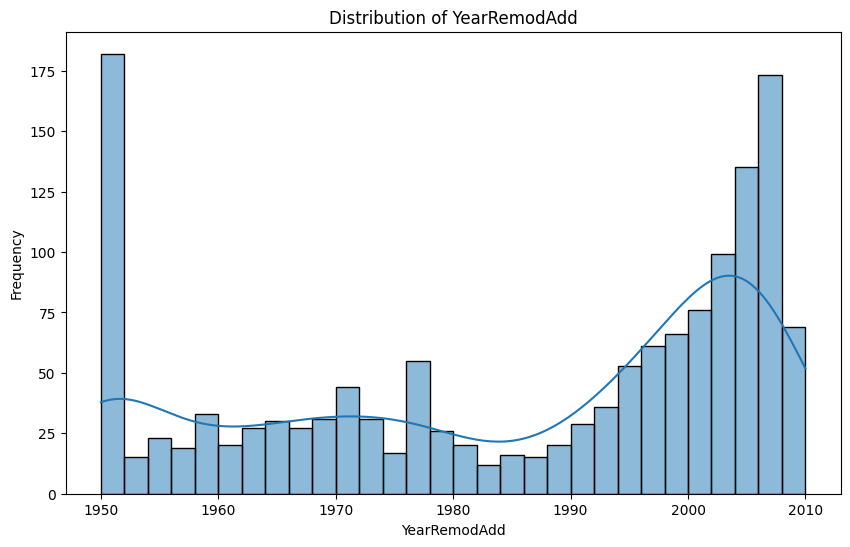

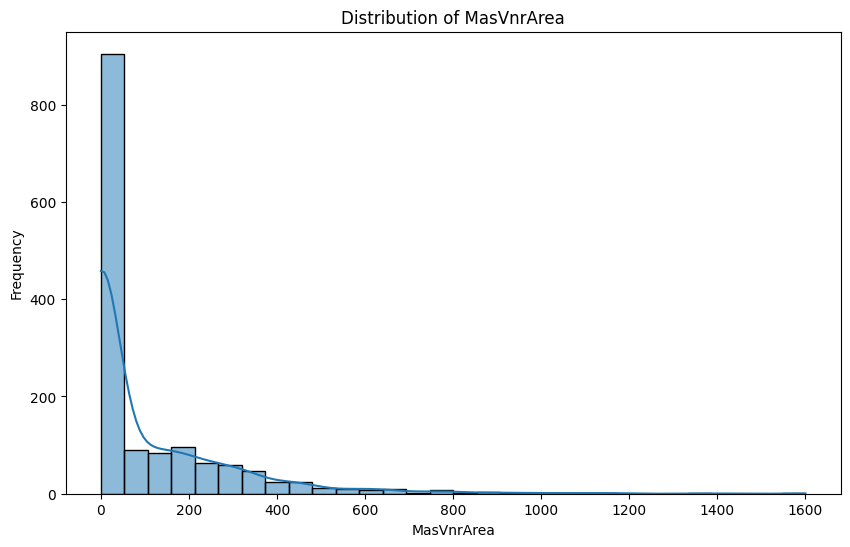

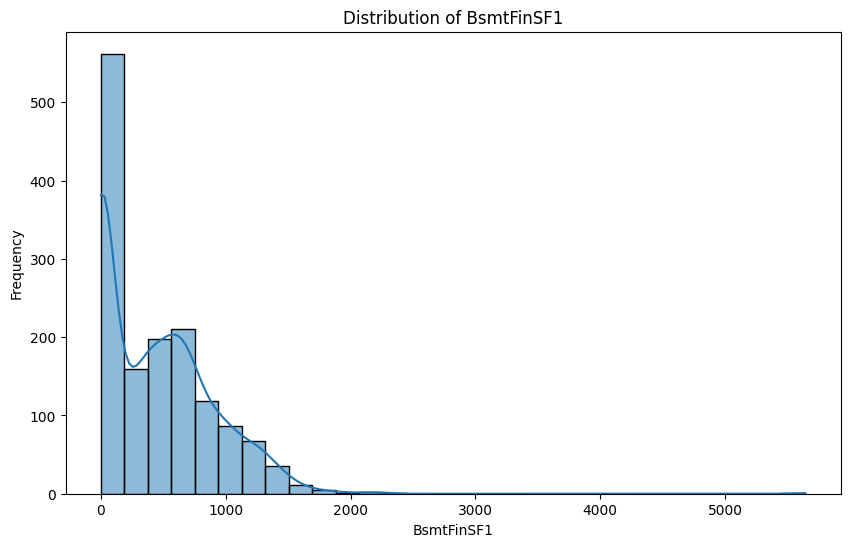

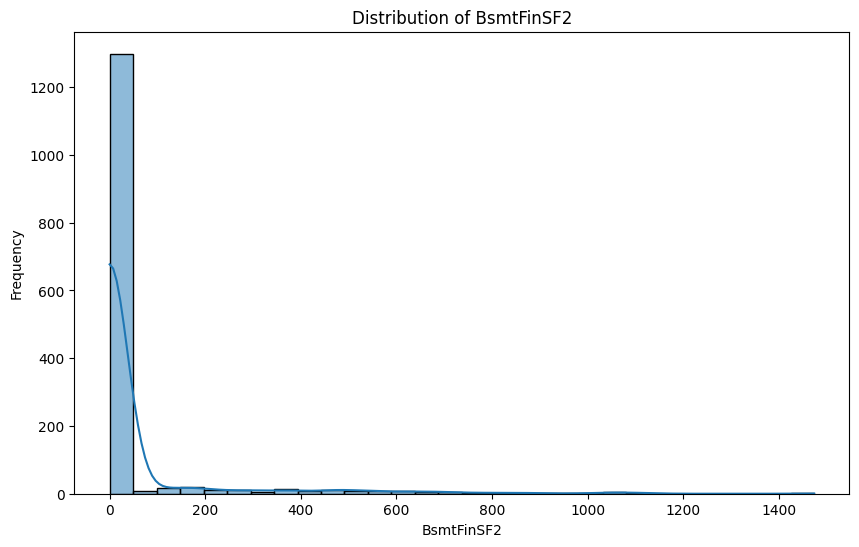

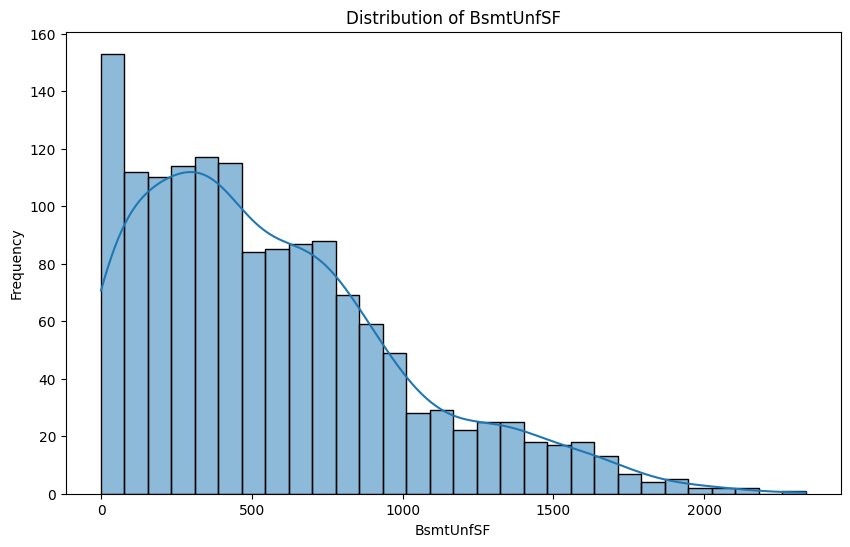

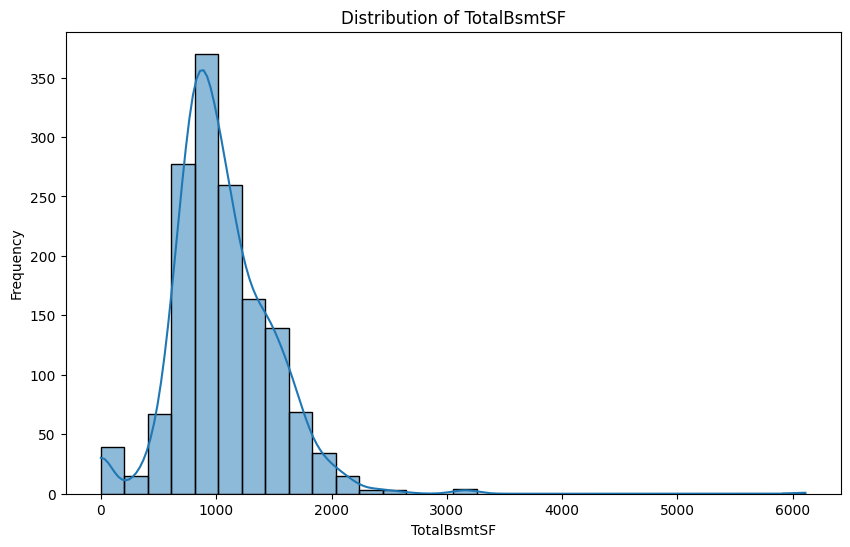

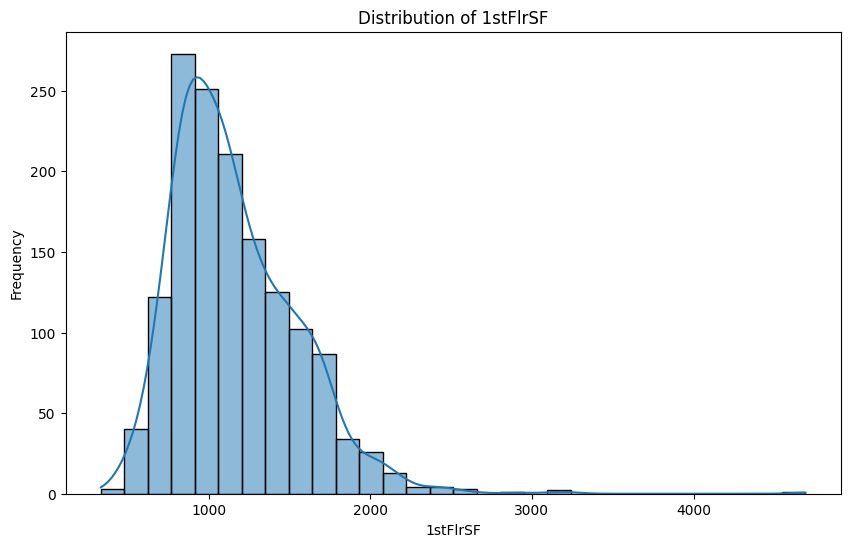

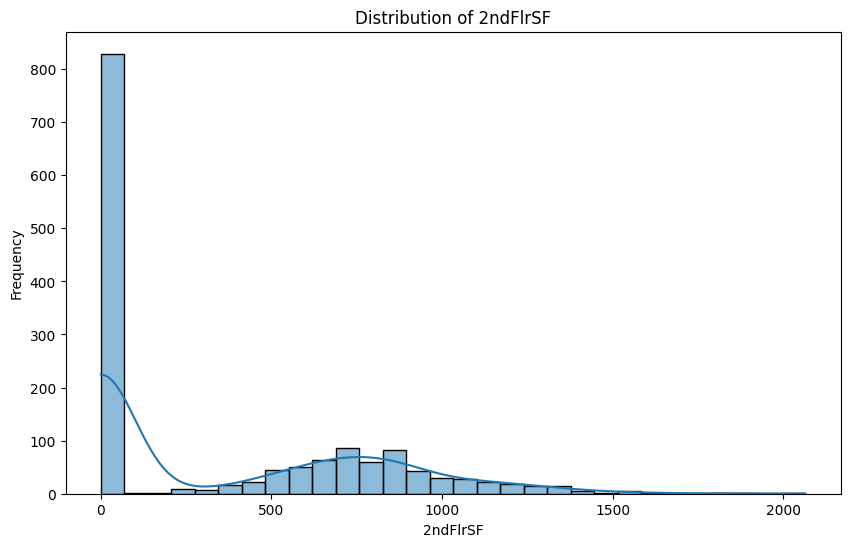

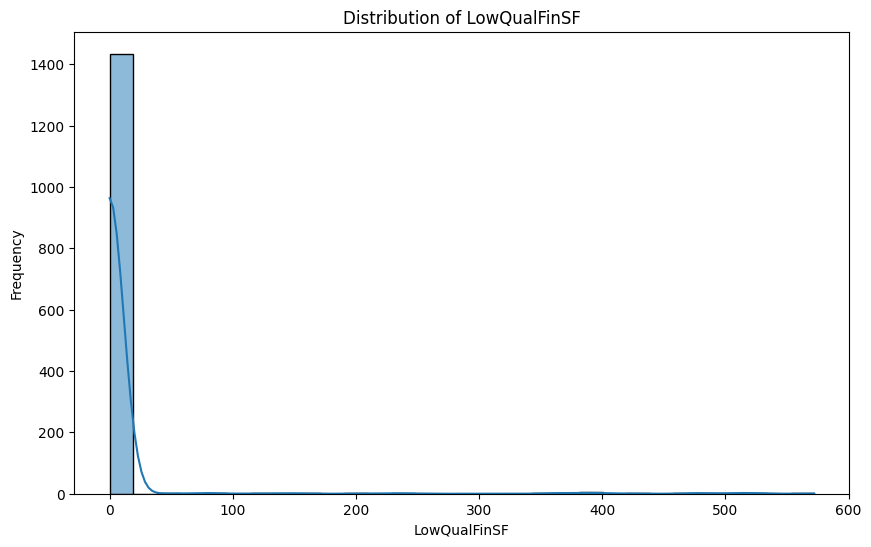

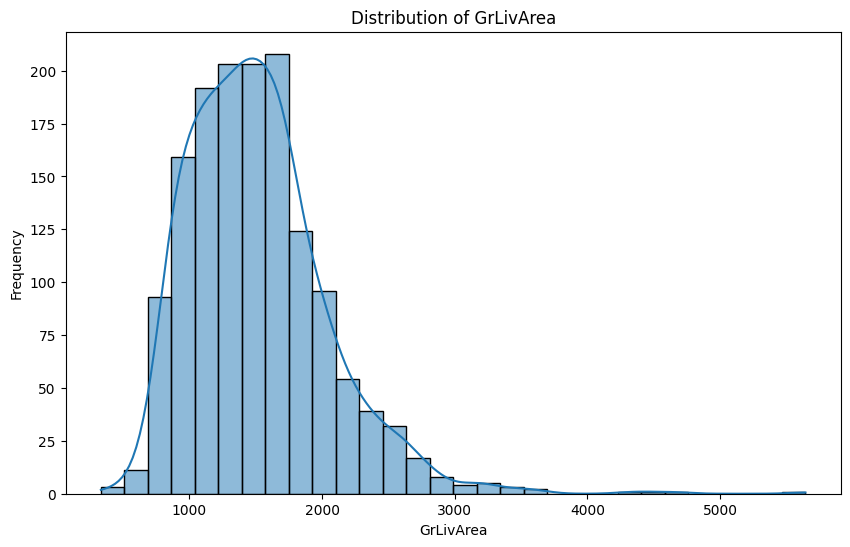

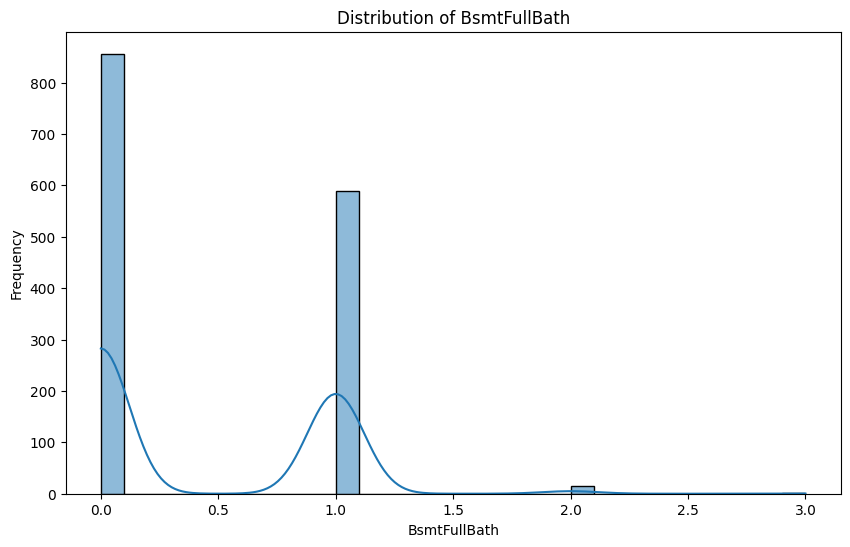

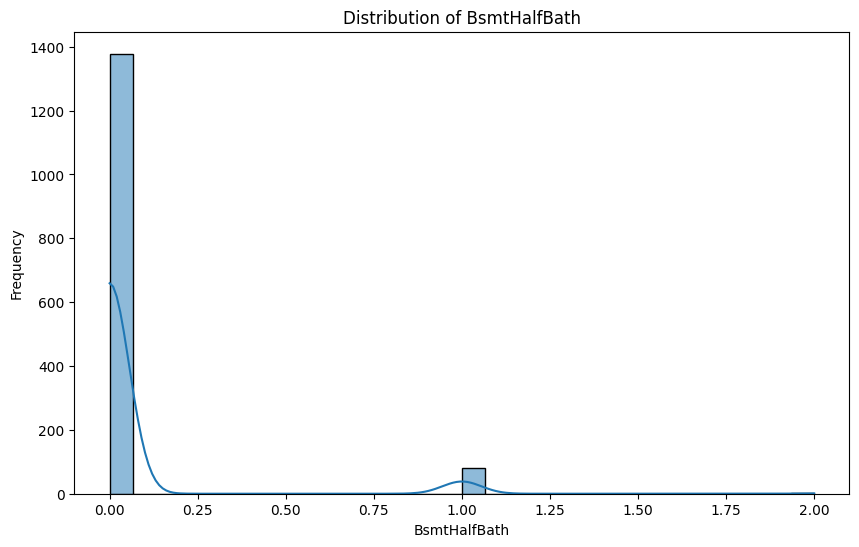

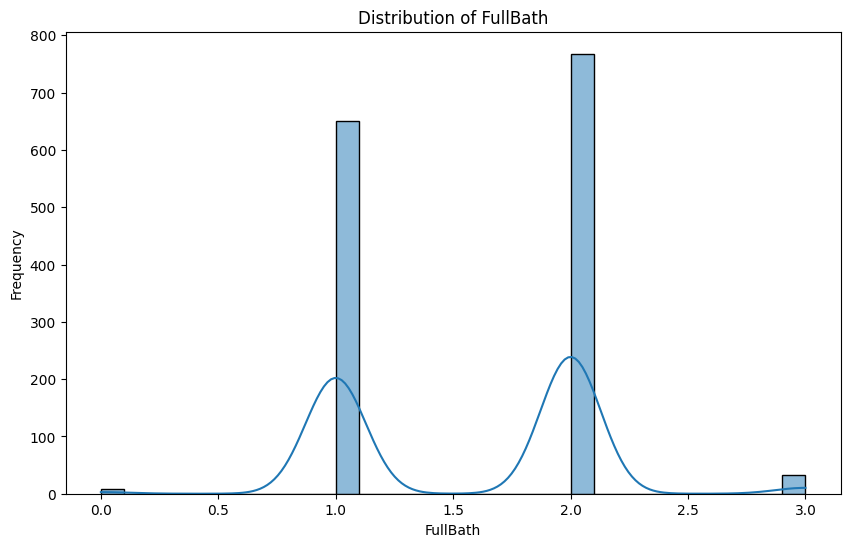

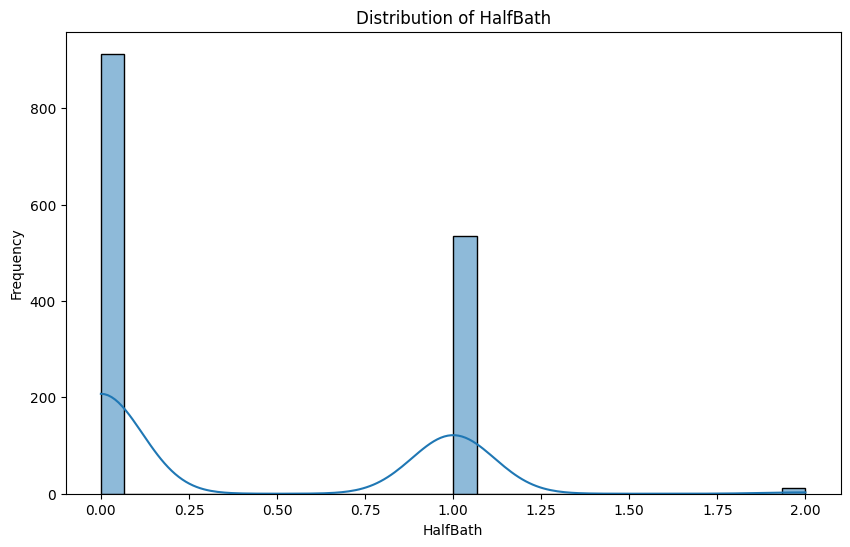

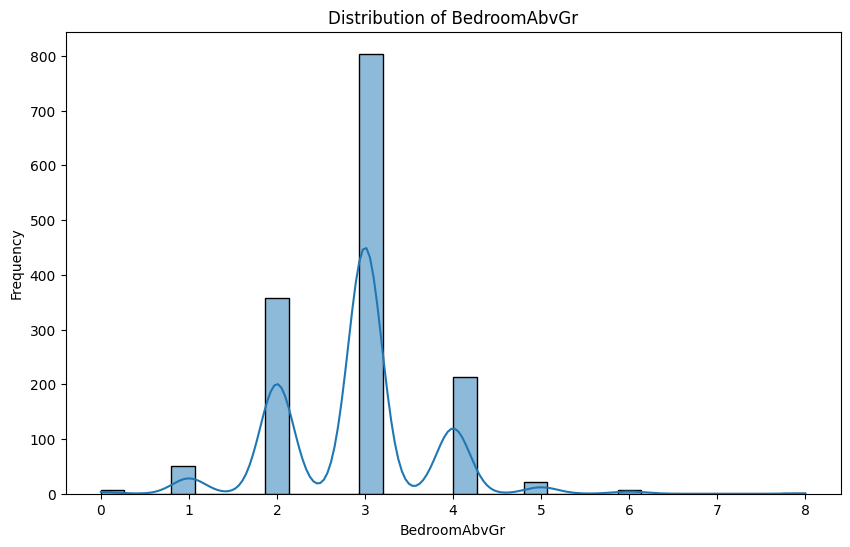

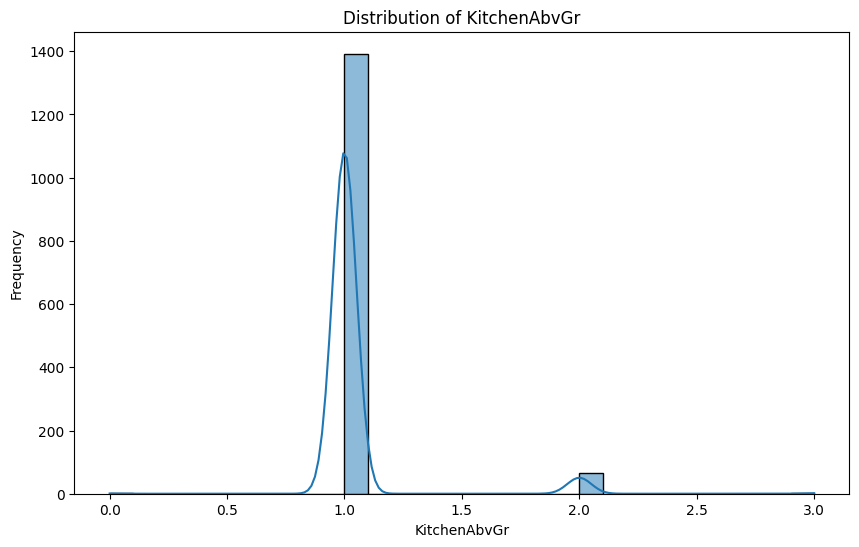

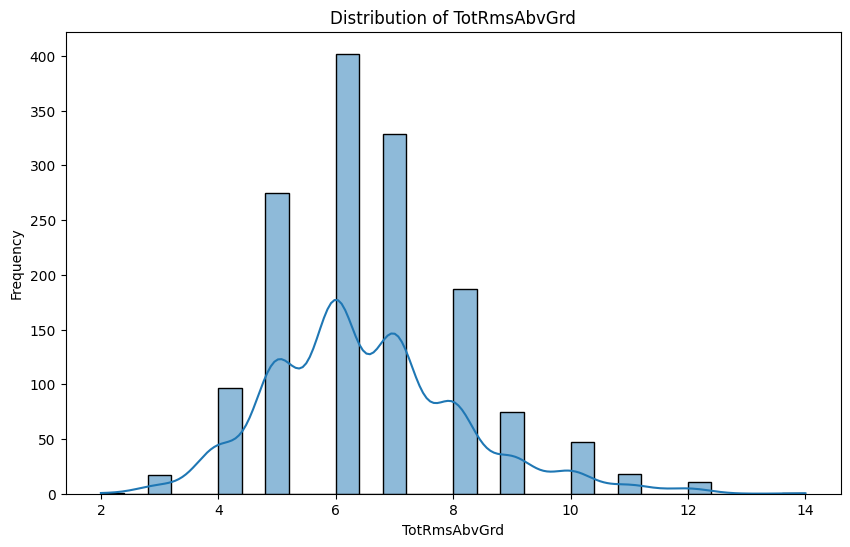

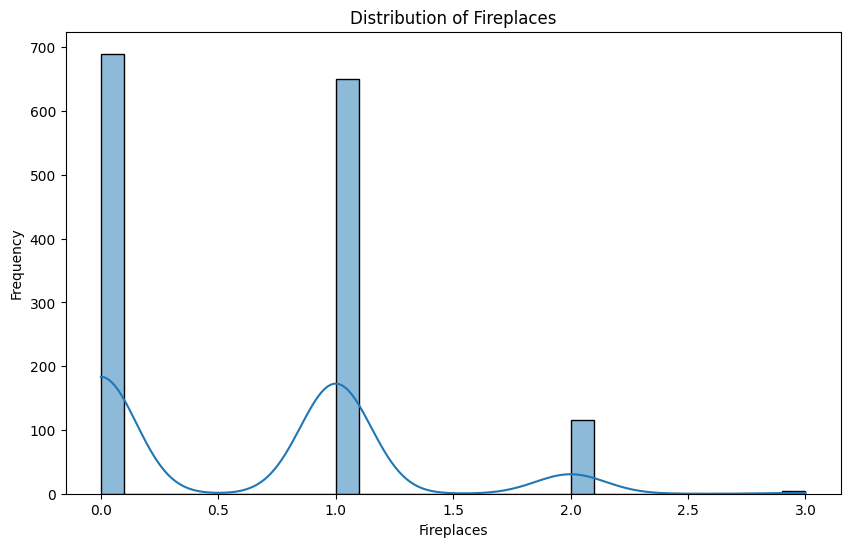

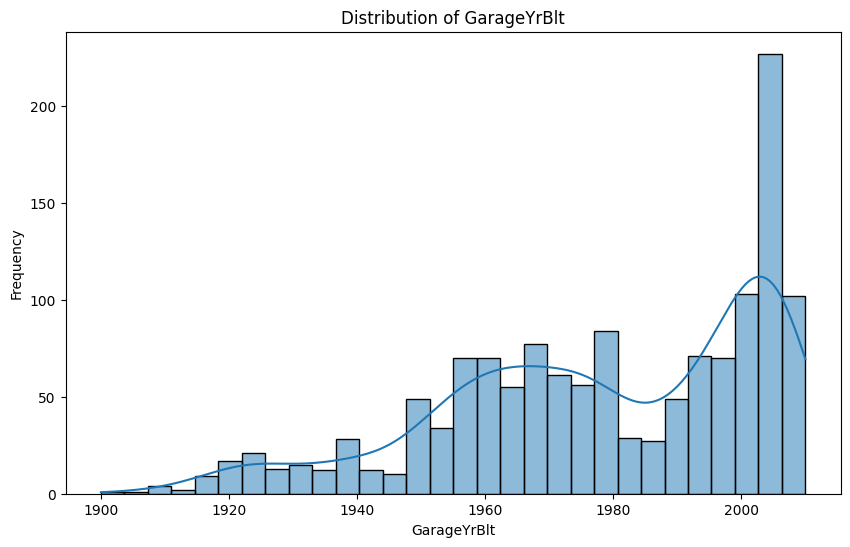

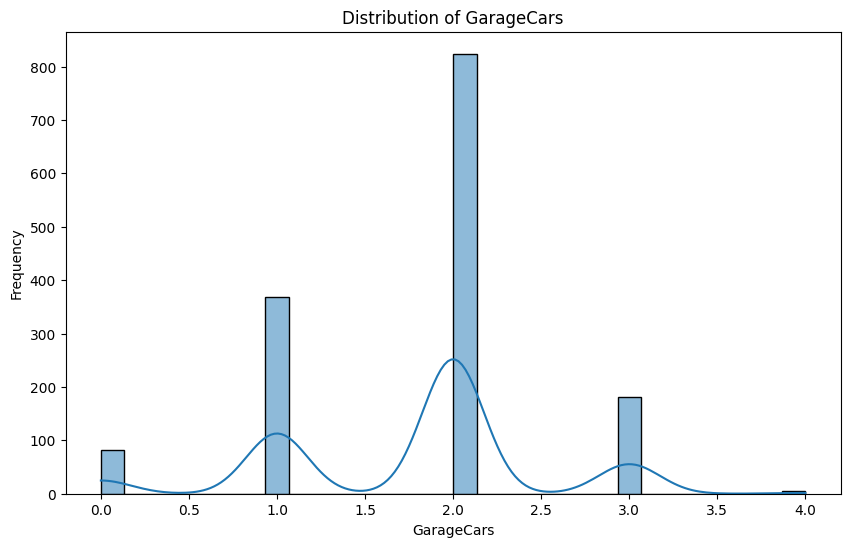

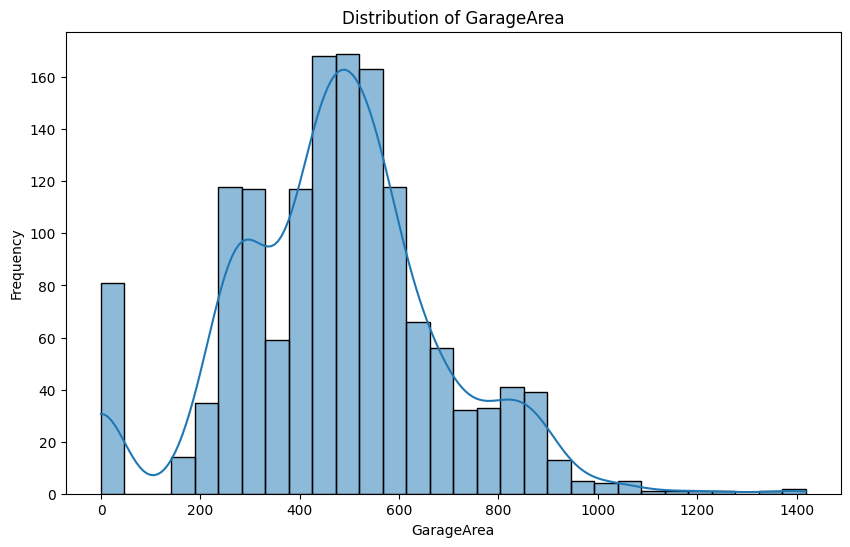

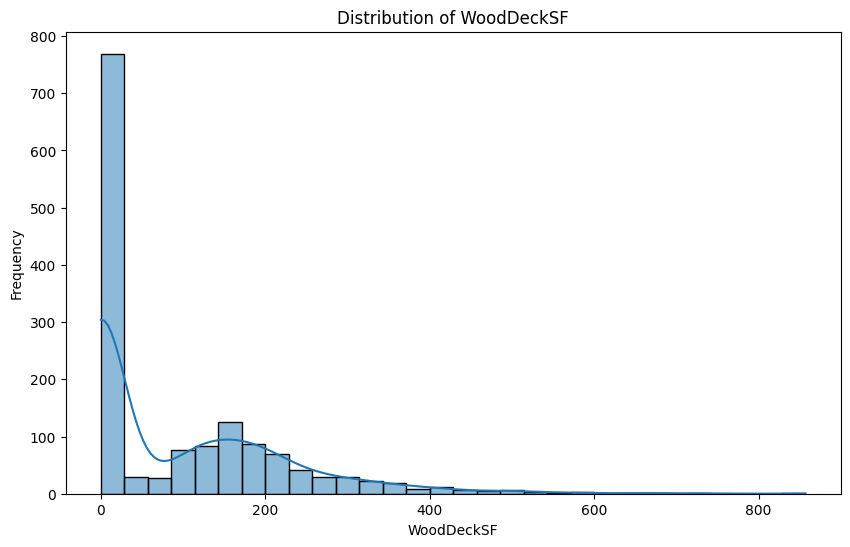

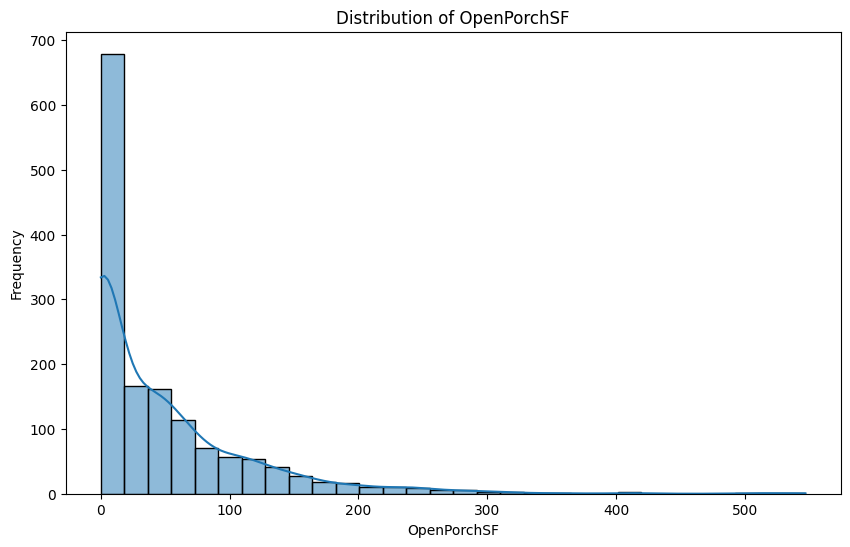

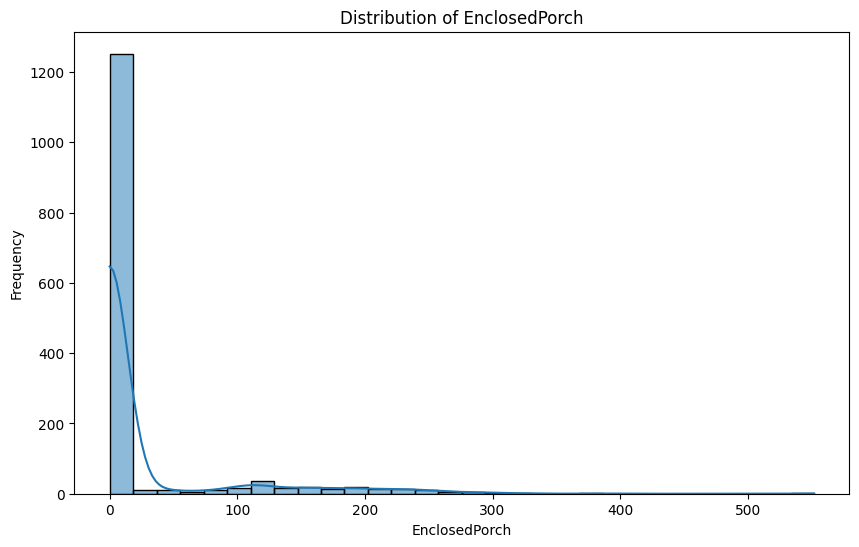

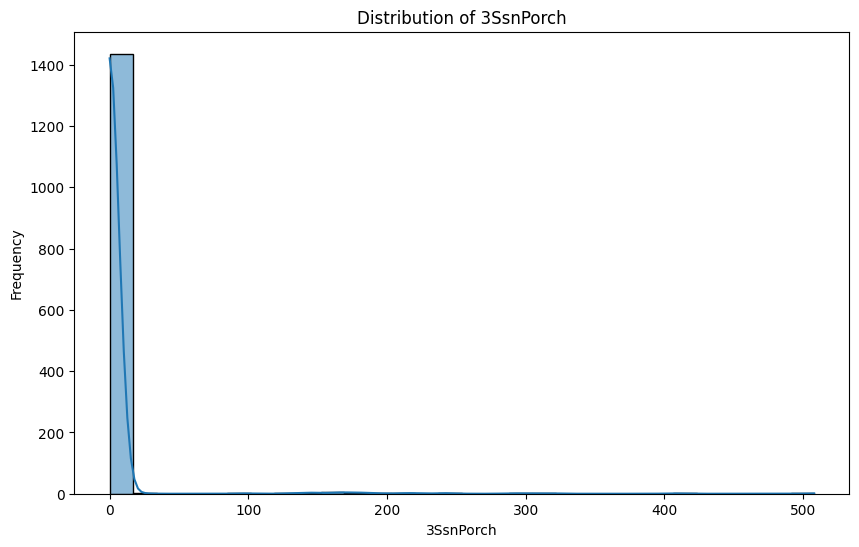

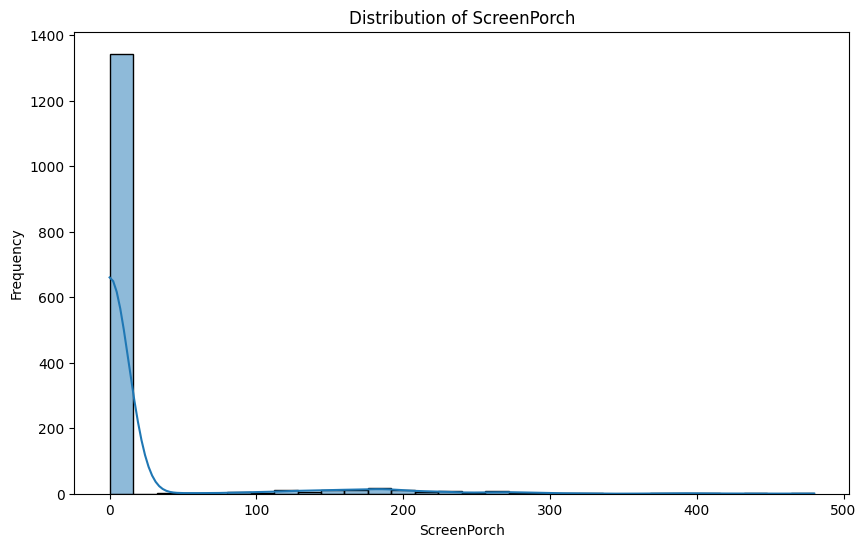

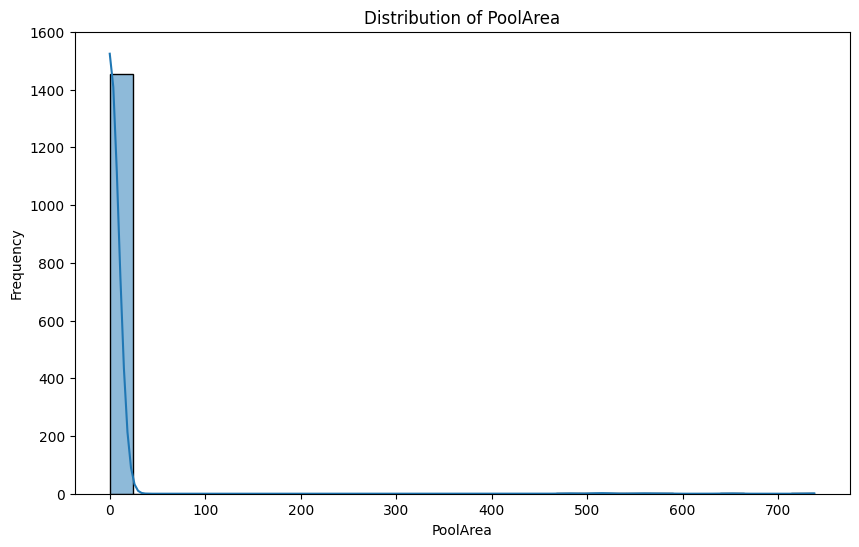

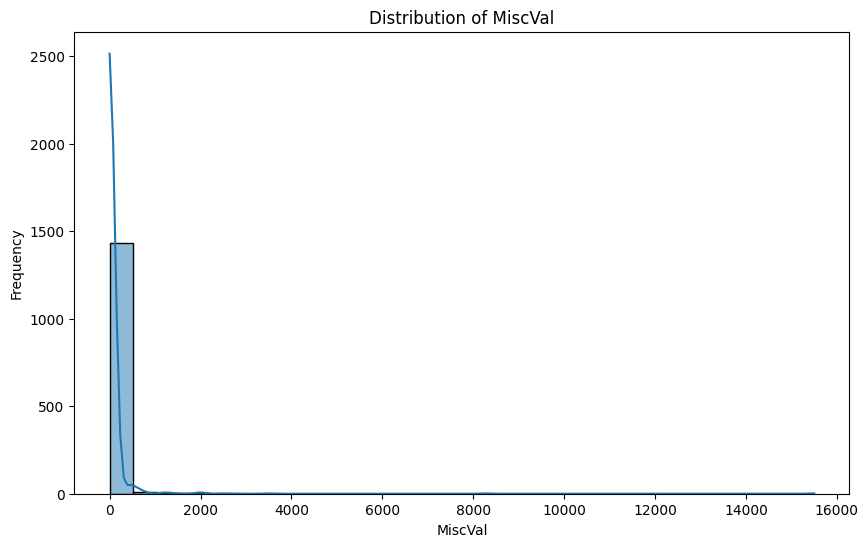

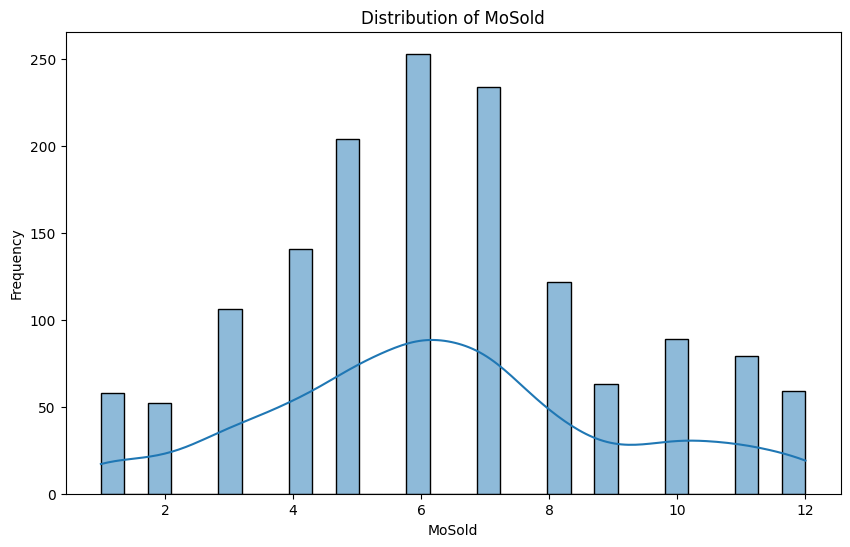

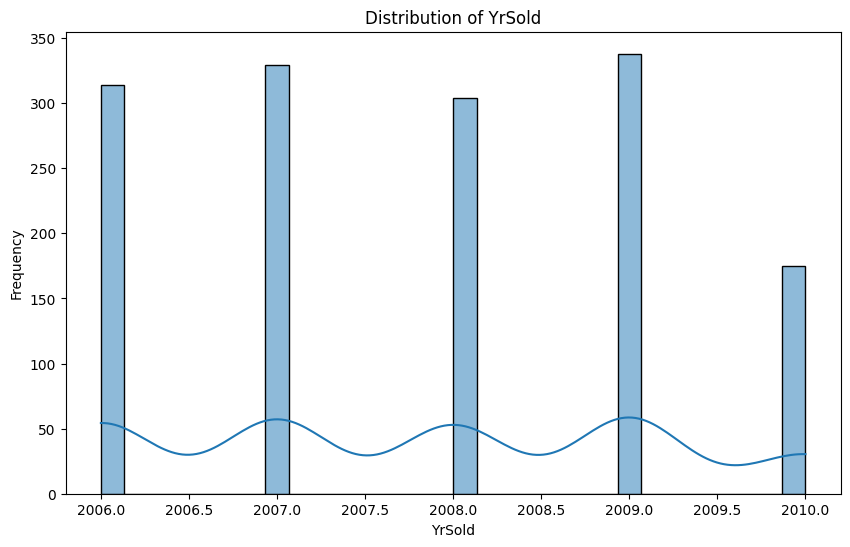

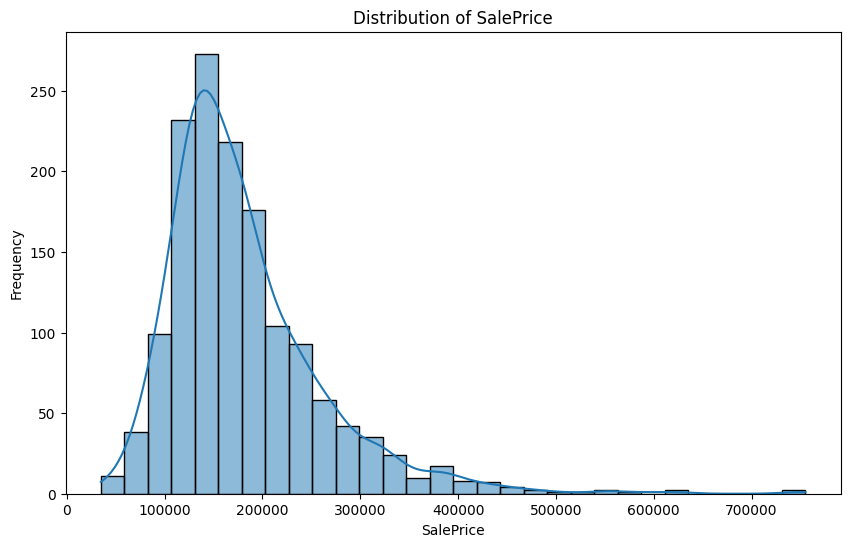

Top 5 Skewed Features:
MiscVal         24.476794
PoolArea        14.828374
LotArea         12.207688
3SsnPorch       10.304342
LowQualFinSF     9.011341
dtype: float64


In [3]:
numeric_features = (
    df_train.drop(["Id"], axis=1).select_dtypes(include=["int64", "float64"]).columns
)

print("Hist plot for numeric features:")
for feature in df_train[numeric_features]:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_train[feature], bins=30, kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

top_5_skewed_features = (
    df_train[numeric_features].skew().sort_values(ascending=False).head(5)
)
print("Top 5 Skewed Features:")
print(top_5_skewed_features)

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, '2Story'),
  Text(1, 0, '1Story'),
  Text(2, 0, '1.5Fin'),
  Text(3, 0, '1.5Unf'),
  Text(4, 0, 'SFoyer'),
  Text(5, 0, 'SLvl'),
  Text(6, 0, '2.5Unf'),
  Text(7, 0, '2.5Fin')])

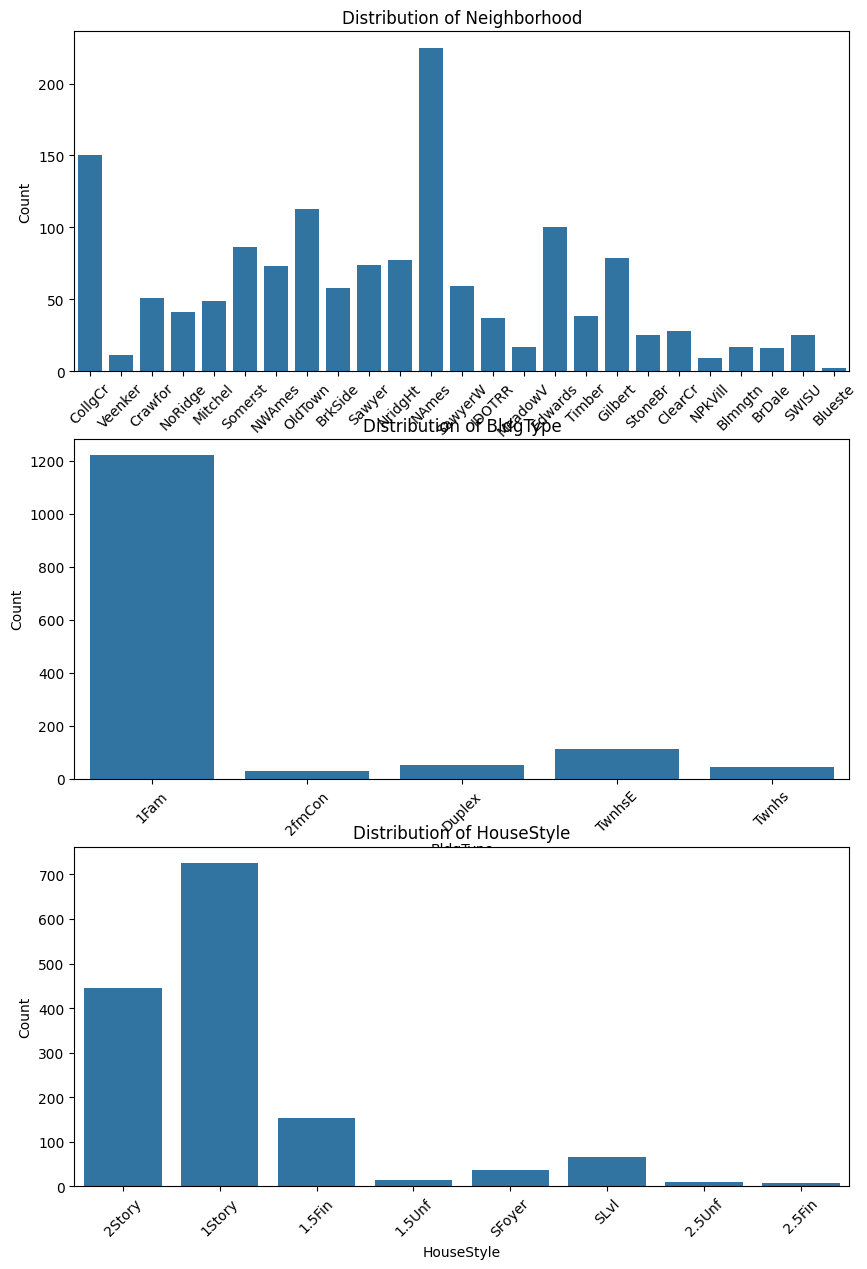

In [4]:
plt.figure(figsize=(10, 15))
plt.subplot(3, 1, 1)
sns.countplot(x="Neighborhood", data=df_train)
plt.title("Distribution of Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.subplot(3, 1, 2)
sns.countplot(x="BldgType", data=df_train)
plt.title("Distribution of BldgType")
plt.xlabel("BldgType")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.subplot(3, 1, 3)
sns.countplot(x="HouseStyle", data=df_train)
plt.title("Distribution of HouseStyle")
plt.xlabel("HouseStyle")
plt.ylabel("Count")
plt.xticks(rotation=45)

Top 15 Features Most Correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


<Axes: >

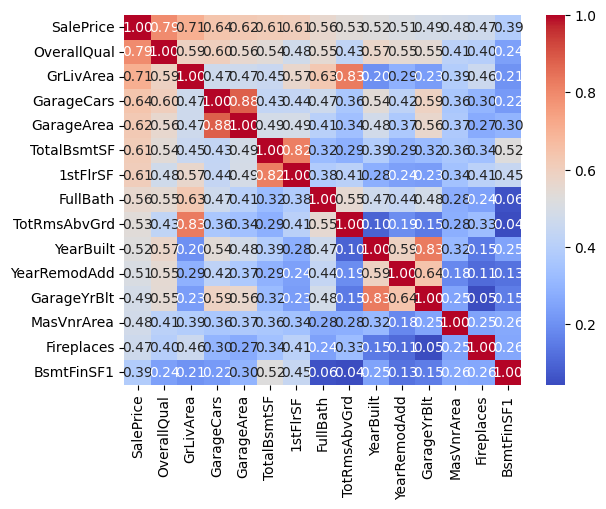

In [5]:
correlation_matrix = df_train[numeric_features].corr()
saleprice_correlation = correlation_matrix["SalePrice"].sort_values(ascending=False)
top_15_features = saleprice_correlation.head(15).index
print("Top 15 Features Most Correlated with SalePrice:")
print(saleprice_correlation.head(15))
sns.heatmap(df_train[top_15_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")

Text(0, 0.5, 'SalePrice')

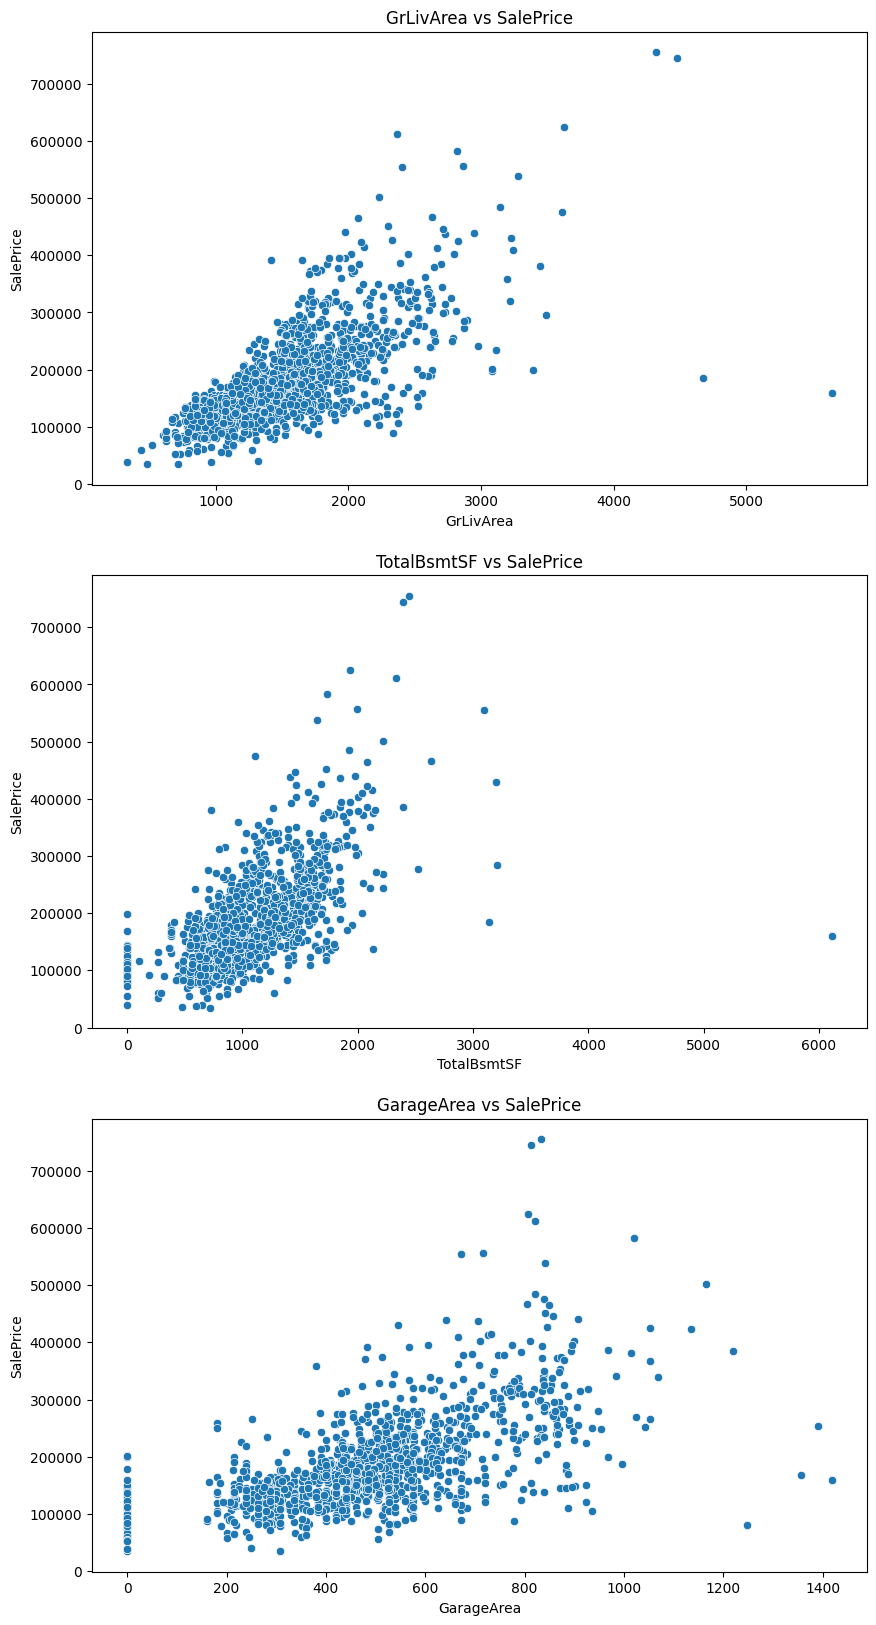

In [6]:
plt.figure(figsize=(10, 20))
plt.subplot(3, 1, 1)
sns.scatterplot(x="GrLivArea", y="SalePrice", data=df_train)
plt.title("GrLivArea vs SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.subplot(3, 1, 2)
sns.scatterplot(x="TotalBsmtSF", y="SalePrice", data=df_train)
plt.title("TotalBsmtSF vs SalePrice")
plt.xlabel("TotalBsmtSF")
plt.ylabel("SalePrice")
plt.subplot(3, 1, 3)
sns.scatterplot(x="GarageArea", y="SalePrice", data=df_train)
plt.title("GarageArea vs SalePrice")
plt.xlabel("GarageArea")
plt.ylabel("SalePrice")

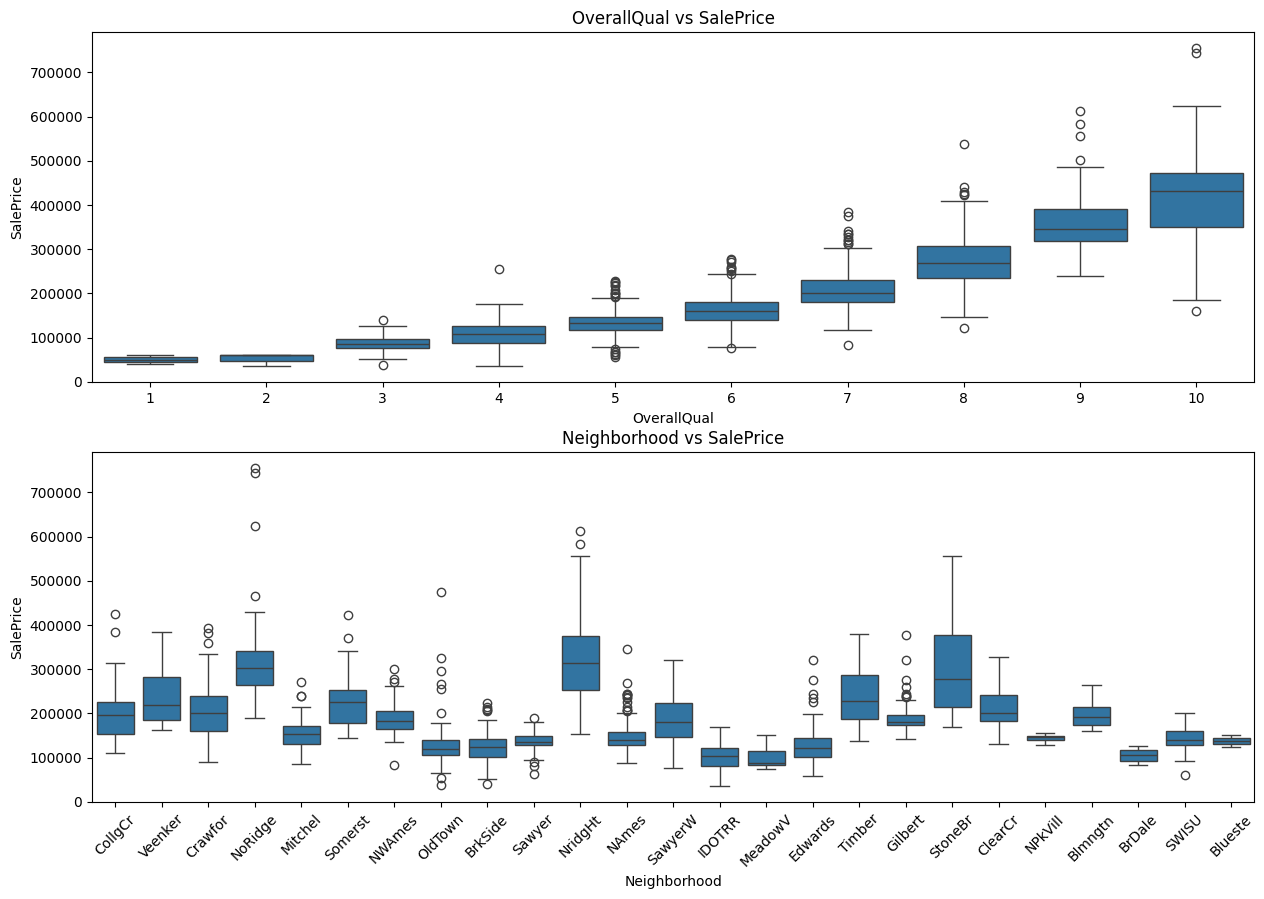

Priciest Neighborhoods based on Median SalePrice:
Neighborhood
NridgHt    315000.0
NoRidge    301500.0
StoneBr    278000.0
Timber     228475.0
Somerst    225500.0
Veenker    218000.0
Crawfor    200624.0
ClearCr    200250.0
CollgCr    197200.0
Blmngtn    191000.0
NWAmes     182900.0
Gilbert    181000.0
SawyerW    179900.0
Mitchel    153500.0
NPkVill    146000.0
NAmes      140000.0
SWISU      139500.0
Blueste    137500.0
Sawyer     135000.0
BrkSide    124300.0
Edwards    121750.0
OldTown    119000.0
BrDale     106000.0
IDOTRR     103000.0
MeadowV     88000.0
Name: SalePrice, dtype: float64


In [7]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 1, 1)
sns.boxplot(x="OverallQual", y="SalePrice", data=df_train)
plt.title("OverallQual vs SalePrice")
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.subplot(2, 1, 2)
sns.boxplot(x="Neighborhood", y="SalePrice", data=df_train)
plt.title("Neighborhood vs SalePrice")
plt.xlabel("Neighborhood")
plt.ylabel("SalePrice")
plt.xticks(rotation=45)
plt.show()

print("Priciest Neighborhoods based on Median SalePrice:")
neighborhood_medians = (
    df_train.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False)
)
print(neighborhood_medians)

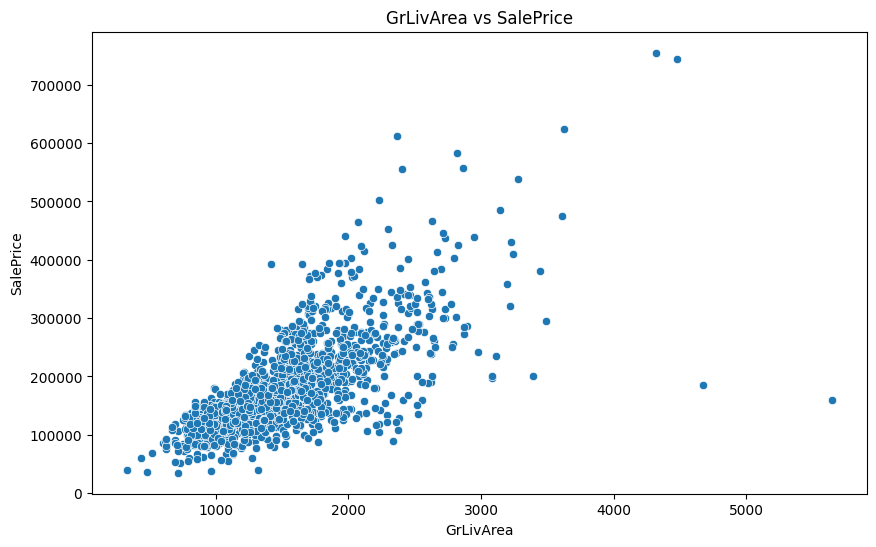

Two Extreme Outliers in GrLivArea vs SalePrice:
      GrLivArea  SalePrice
523        4676     184750
1298       5642     160000


In [8]:
# Identify and flag any outliers visible in GrLivArea vs SalePrice (hint: two extreme points exist).
plt.figure(figsize=(10, 6))
sns.scatterplot(x="GrLivArea", y="SalePrice", data=df_train)
plt.title("GrLivArea vs SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

two_extreme_outliers = df_train[
    (df_train["GrLivArea"] > 4000) & (df_train["SalePrice"] < 300000)
]

print("Two Extreme Outliers in GrLivArea vs SalePrice:")
print(two_extreme_outliers[["GrLivArea", "SalePrice"]])

---


## **🔧 Step 3: Data Preprocessing & Feature Engineering**

3.1 Handle Missing Values

- Report all columns with missing values and their missing %.
- For categorical columns where NaN means 'None' (e.g., PoolQC, Fence, GarageType) — fill with 'None'.
- For numerical columns where NaN means 0 (e.g., GarageArea, BsmtFinSF1) — fill with 0.
- For remaining numerical columns — fill with median.
- Drop columns with >80% missing values.

  3.2 Outlier Removal

- Remove the 2 outlier rows in GrLivArea where GrLivArea > 4000 and SalePrice < 300,000.
- Briefly explain why keeping these outliers would harm a linear model.

  3.3 Feature Engineering

- Create TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF (total usable area).
- Create HouseAge = YrSold - YearBuilt.
- Create RemodAge = YrSold - YearRemodAdd.
- Create HasGarage = 1 if GarageArea > 0 else 0.
- Create HasPool = 1 if PoolArea > 0 else 0.

  3.4 Encoding & Scaling

- Apply Ordinal Encoding to quality/condition columns: ExterQual, KitchenQual, BsmtQual, FireplaceQu (map: Po→1, Fa→2, TA→3, Gd→4, Ex→5, None→0).
- Apply One-Hot Encoding to nominal categoricals with ≤10 unique values (e.g., BldgType, HouseStyle, SaleCondition).
- Drop or label-encode high-cardinality columns (Neighborhood: use mean-target encoding or label encode).
- Apply log1p transformation to skewed numerical features (skewness > 0.75).
- Apply StandardScaler to all continuous numerical features.
- Use ColumnTransformer + Pipeline to chain all transformations cleanly.

  3.5 Train-Test Split

- Apply log1p to y (SalePrice) before splitting — this is your target.
- Split: 80% train / 20% test using random_state=42.
- Print shapes of X_train, X_test, y_train, y_test.


In [9]:
# - Report all columns with missing values and their missing %.
# - For categorical columns where NaN means 'None' (e.g., PoolQC, Fence, GarageType) — fill with 'None'.
# - For numerical columns where NaN means 0 (e.g., GarageArea, BsmtFinSF1) — fill with 0.
# - For remaining numerical columns — fill with median.
# - Drop columns with >80% missing values.

missing_values = df_train.isnull().sum()
missing_percentage = (missing_values / len(df_train)) * 100

print("Columns with Missing Values and Their Missing Percentage:")
for column, missing in missing_values.items():
    if missing > 0:
        print(f"{column}: {missing} missing values ({missing_percentage[column]:.2f}%)")

none_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
]

for column in none_cols:
    if column in df_train.columns:
        df_train[column] = df_train[column].fillna("None")

print(f"\nFilled categorical columns with 'None' where applicable.\n{none_cols}")


zero_cols = [
    "GarageArea",
    "GarageCars",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "MasVnrArea",
]

for column in zero_cols:
    if column in df_train.columns:
        df_train[column] = df_train[column].fillna(0)

print(f"\nFilled numerical columns with 0 where applicable.\n{zero_cols}")

median_cols = ["LotFrontage", "MasVnrArea", "GarageYrBlt"]

for column in median_cols:
    if column in df_train.columns:
        median_value = df_train[column].median()
        df_train[column] = df_train[column].fillna(median_value)

print(
    f"\nFilled remaining numerical columns with median where applicable.\n{median_cols}"
)

if columns_with_missing := df_train.columns[df_train.isnull().any()].tolist():
    print(f"\nColumns still with missing values after filling: {columns_with_missing}")

if columns_to_drop := df_train.columns[missing_percentage > 80].tolist():
    print(f"\nColumns to drop ( >80% missing): {columns_to_drop}")
    df_train = df_train.drop(columns=columns_to_drop)

columns_remaining = df_train.columns[df_train.isnull().any()].tolist()
for column in columns_remaining:
    if df_train[column].dtype == "object":
        mode_value = df_train[column].mode()[0]
        df_train[column] = df_train[column].fillna(mode_value)
    else:
        median_value = df_train[column].median()
        df_train[column] = df_train[column].fillna(median_value)

print("\nRemaining missing values:")
print(df_train.isnull().sum()[df_train.isnull().sum() > 0])

Columns with Missing Values and Their Missing Percentage:
LotFrontage: 259 missing values (17.74%)
Alley: 1369 missing values (93.77%)
MasVnrType: 872 missing values (59.73%)
MasVnrArea: 8 missing values (0.55%)
BsmtQual: 37 missing values (2.53%)
BsmtCond: 37 missing values (2.53%)
BsmtExposure: 38 missing values (2.60%)
BsmtFinType1: 37 missing values (2.53%)
BsmtFinType2: 38 missing values (2.60%)
Electrical: 1 missing values (0.07%)
FireplaceQu: 690 missing values (47.26%)
GarageType: 81 missing values (5.55%)
GarageYrBlt: 81 missing values (5.55%)
GarageFinish: 81 missing values (5.55%)
GarageQual: 81 missing values (5.55%)
GarageCond: 81 missing values (5.55%)
PoolQC: 1453 missing values (99.52%)
Fence: 1179 missing values (80.75%)
MiscFeature: 1406 missing values (96.30%)

Filled categorical columns with 'None' where applicable.
['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposu

In [10]:
# - Remove the 2 outlier rows in GrLivArea where GrLivArea > 4000 and SalePrice < 300,000.
# - Briefly explain why keeping these outliers would harm a linear model.

df_train = df_train.drop(two_extreme_outliers.index)

#### Briefly explain why keeping these outliers would harm a linear model.

Keeping these outliers would harm a linear model because they can significantly skew the regression line, leading to poor predictions for the majority of the data. Outliers have a disproportionate influence on the model's coefficients, which can result in a model that does not accurately represent the underlying relationship between the variables.


In [11]:
# - Create TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF (total usable area).
# - Create HouseAge = YrSold - YearBuilt.
# - Create RemodAge = YrSold - YearRemodAdd.
# - Create HasGarage = 1 if GarageArea > 0 else 0.
# - Create HasPool = 1 if PoolArea > 0 else 0.

df_train["TotalSF"] = (
    df_train["TotalBsmtSF"] + df_train["1stFlrSF"] + df_train["2ndFlrSF"]
)
df_train["HouseAge"] = df_train["YrSold"] - df_train["YearBuilt"]
df_train["RemodAge"] = df_train["YrSold"] - df_train["YearRemodAdd"]
df_train["HasGarage"] = df_train["GarageArea"].apply(lambda x: 1 if x > 0 else 0)
df_train["HasPool"] = df_train["PoolArea"].apply(lambda x: 1 if x > 0 else 0)

In [12]:
# - Apply Ordinal Encoding to quality/condition columns: ExterQual, KitchenQual, BsmtQual, FireplaceQu (map: Po→1, Fa→2, TA→3, Gd→4, Ex→5, None→0).
# - Apply One-Hot Encoding to nominal categoricals with ≤10 unique values (e.g., BldgType, HouseStyle, SaleCondition).
# - Drop or label-encode high-cardinality columns (Neighborhood: use mean-target encoding or label encode).
# - Apply log1p transformation to skewed numerical features (skewness > 0.75).
# - Apply StandardScaler to all continuous numerical features.
# - Use ColumnTransformer + Pipeline to chain all transformations cleanly.

ordinal_features = ["ExterQual", "KitchenQual", "BsmtQual", "FireplaceQu"]

ordinal_mapping = {
    "ExterQual": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtQual": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "FireplaceQu": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
}

ordinal_encoder = OrdinalEncoder(
    categories=[ordinal_mapping[feature] for feature in ordinal_features]
)
ordinal_transformer = Pipeline(steps=[("ordinal_encoder", ordinal_encoder)])

ordinal_transformer.fit(df_train[ordinal_features])

ordinal_encoded = ordinal_transformer.transform(df_train[ordinal_features])

one_hot_features = ["BldgType", "HouseStyle", "SaleCondition"]

one_hot_encoder = OneHotEncoder(handle_unknown="ignore")

one_hot_transformer = Pipeline(steps=[("one_hot_encoder", one_hot_encoder)])

one_hot_transformer.fit(df_train[one_hot_features])

one_hot_encoded = one_hot_transformer.transform(df_train[one_hot_features])

neighborhood_features = ["Neighborhood"]
neighborhood_encoder = OneHotEncoder(handle_unknown="ignore")
neighborhood_transformer = Pipeline(steps=[("neighborhood_encoder", neighborhood_encoder)])
neighborhood_transformer.fit(df_train[["Neighborhood"]])
neighborhood_encoded = neighborhood_transformer.transform(df_train[["Neighborhood"]])

skewed_features = df_train[numeric_features].skew().sort_values(ascending=False)
skewed_features = skewed_features[skewed_features > 0.75].index
skewed_transformer = FunctionTransformer(np.log1p, validate=True)
skewed_transformer.fit(df_train[skewed_features])
skewed_transformed = skewed_transformer.transform(df_train[skewed_features])

continuous_features = df_train[numeric_features].columns.difference(skewed_features)
standard_scaler = StandardScaler()
standard_scaler.fit(df_train[continuous_features])
continuous_transformed = standard_scaler.transform(df_train[continuous_features])

column_transformer = ColumnTransformer(
    transformers=[
        ("ordinal", ordinal_transformer, ordinal_features),
        ("one_hot", one_hot_transformer, one_hot_features),
        ("neighborhood", neighborhood_transformer, neighborhood_features),
        ("skewed", skewed_transformer, skewed_features),
        ("continuous", standard_scaler, continuous_features),
    ],
    remainder="drop",
)

column_transformer.fit(df_train)

df_train_not_transformed = df_train.copy()
df_train = pd.DataFrame(column_transformer.transform(df_train))

In [13]:
# - Apply log1p to y (SalePrice) before splitting — this is your target.
# - Split: 80% train / 20% test using random_state=42.
# - Print shapes of X_train, X_test, y_train, y_test.
df_train["SalePrice"] = np.log1p(df_train_not_transformed["SalePrice"])

valid_train = df_train["SalePrice"].notna()

df_train_not_valid = df_train.copy()
df_train = df_train[valid_train]

X_train, X_test, y_train, y_test = train_test_split(
    df_train.drop(columns=["SalePrice"]),
    df_train["SalePrice"],
    test_size=0.2,
    random_state=42,
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

unknown_data = pd.read_csv("data/test.csv")

X_train shape: (1164, 85)
X_test shape: (292, 85)
y_train shape: (1164,)
y_test shape: (292,)


---


## **📐 Step 4: Regression Models — Linear, Ridge & Lasso**

**4.1 Linear Regression (Baseline)**

- Train a LinearRegression model. Predict on `X_test`.
- Report: RMSE, MAE, R² on test set (remember to expm1 your predictions before computing metrics on original scale).
- Plot: Actual vs Predicted scatter plot. A perfect model falls on the diagonal — how close are you?

**4.2 Ridge Regression (L2)**

- Train `RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])` — let it auto-select the best alpha.
- Print the best alpha selected.
- Report: RMSE, MAE, R² on test set.
- Plot coefficients: top 20 most impactful features by absolute coefficient value.

**4.3 Lasso Regression (L1)**

- Train `LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1], max_iter=10000)` — let it auto-select best alpha.
- Print the best alpha and how many features were zeroed out (coefficient = 0).
- Report: RMSE, MAE, R² on test set.
- Compare: which model (Ridge vs Lasso) performed better and why?



Linear Regression Evaluation Metrics:
RMSE: 71813.1311
MAE: 52750.3621
R²: 0.0721


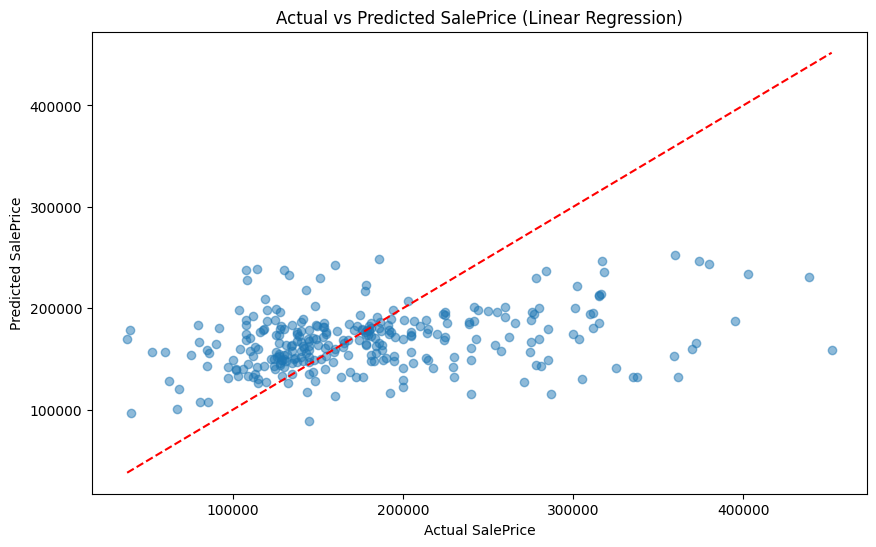

In [14]:
# - Train a LinearRegression model. Predict on `X_test`.
# - Report: RMSE, MAE, R² on test set (remember to expm1 your predictions before computing metrics on original scale).
# - Plot: Actual vs Predicted scatter plot. A perfect model falls on the diagonal — how close are you?

lr_model = LinearRegression()
df_train_not_valid = df_train.copy()

lr_model.fit(
    X_train,
    y_train,
)
y_pred_lr = lr_model.predict(X_test)

eval_metrics = {}

eval_metrics["Linear Regression"] = {
    "RMSE": root_mean_squared_error(np.expm1(y_test), np.expm1(y_pred_lr)),
    "MAE": mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_lr)),
    "R²": r2_score(np.expm1(y_test), np.expm1(y_pred_lr)),
}

print(f"\nLinear Regression Evaluation Metrics:")
for metric_name, value in eval_metrics["Linear Regression"].items():
    print(f"{metric_name}: {value:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(np.expm1(y_test), np.expm1(y_pred_lr), alpha=0.5)
plt.plot([np.expm1(y_test).min(), np.expm1(y_test).max()], [np.expm1(y_test).min(), np.expm1(y_test).max()], "r--")
plt.title("Actual vs Predicted SalePrice (Linear Regression)")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.show()

In [15]:
# - Train `RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])` — let it auto-select the best alpha.
# - Print the best alpha selected.
# - Report: RMSE, MAE, R² on test set.
# - Plot coefficients: top 20 most impactful features by absolute coefficient value.

ridge_model = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
print(f"\nBest alpha selected by RidgeCV: {ridge_model.alpha_}")

eval_metrics["Ridge Regression"] = {
    "RMSE": root_mean_squared_error(np.expm1(y_test), np.expm1(y_pred_ridge)),
    "MAE": mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_ridge)),
    "R²": r2_score(np.expm1(y_test), np.expm1(y_pred_ridge)),
}

print(f"\nRidge Regression Evaluation Metrics:")
for metric_name, value in eval_metrics["Ridge Regression"].items():
    print(f"{metric_name}: {value:.4f}")


Best alpha selected by RidgeCV: 100.0

Ridge Regression Evaluation Metrics:
RMSE: 70762.2090
MAE: 50756.7795
R²: 0.0991


In [16]:
# - Train `LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1], max_iter=10000)` — let it auto-select best alpha.
# - Print the best alpha and how many features were zeroed out (coefficient = 0).
# - Report: RMSE, MAE, R² on test set.
# - Compare: which model (Ridge vs Lasso) performed better and why?

lasso_model = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1], max_iter=10000, cv=5)

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)
eval_metrics["Lasso Regression"] = {
    "RMSE": root_mean_squared_error(np.expm1(y_test), np.expm1(y_pred_lasso)),
    "MAE": mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_lasso)),
    "R²": r2_score(np.expm1(y_test), np.expm1(y_pred_lasso)),
}
print(f"Best alpha for Lasso: {lasso_model.alpha_}")
print(f"Number of zeroed-out features for Lasso: {np.sum(lasso_model.coef_ == 0)}")
print(f"\nLasso Regression Evaluation Metrics:")
for metric_name, value in eval_metrics["Lasso Regression"].items():
    print(f"{metric_name}: {value:.4f}")

print("\nRidge vs Lasso Comparison:")
if eval_metrics["Ridge Regression"]["RMSE"] < eval_metrics["Lasso Regression"]["RMSE"]:
    print("Ridge Regression performed better based on RMSE.")
else:
    print("Lasso Regression performed better based on RMSE.")
if eval_metrics["Ridge Regression"]["R²"] > eval_metrics["Lasso Regression"]["R²"]:
    print("Ridge Regression performed better based on R².")
else:
    print("Lasso Regression performed better based on R².")
if eval_metrics["Ridge Regression"]["MAE"] < eval_metrics["Lasso Regression"]["MAE"]:
    print("Ridge Regression performed better based on MAE.")
else:
    print("Lasso Regression performed better based on MAE.")


Best alpha for Lasso: 0.01
Number of zeroed-out features for Lasso: 67

Lasso Regression Evaluation Metrics:
RMSE: 71650.5540
MAE: 51434.5586
R²: 0.0763

Ridge vs Lasso Comparison:
Ridge Regression performed better based on RMSE.
Ridge Regression performed better based on R².
Ridge Regression performed better based on MAE.


---


## **🌳 Step 5: Advanced Models — Random Forest & XGBoost Regressor**

**5.1 Random Forest Regressor**

- Train `RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)`.
- Report: RMSE, MAE, R² on test set.
- Plot feature importances — top 15 features.

**5.2 XGBoost Regressor**

- Train `XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42)`.
- Report: RMSE, MAE, R² on test set.
- Plot feature importances — top 15 features.

**5.3 Cross-Validation (on best model so far)**

- Apply 5-Fold cross-validation using `neg_root_mean_squared_error` on your best-performing model.
- Print mean CV RMSE ± std deviation.
- Does the CV RMSE align with the test set RMSE? Discuss in 2–3 sentences.

**5.4 Hyperparameter Tuning**

- Use `RandomizedSearchCV` on Random Forest or XGBoost (at least 2 hyperparameters, n_iter=20, cv=3).
- Report best parameters and best CV RMSE.
- Re-evaluate the tuned model on the test set.



Random Forest Evaluation Metrics:
RMSE: 71918.6425
MAE: 51855.9025
R²: 0.0694


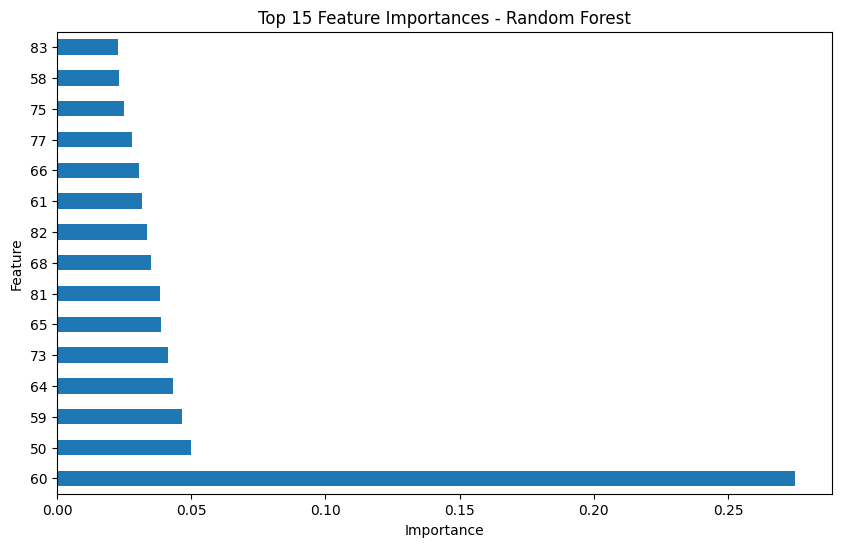

In [17]:
# - Train `RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)`.
# - Report: RMSE, MAE, R² on test set.
# - Plot feature importances — top 15 features.

rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

eval_metrics["Random Forest"] = {
    "RMSE": root_mean_squared_error(np.expm1(y_test), np.expm1(y_pred_rf)),
    "MAE": mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_rf)),
    "R²": r2_score(np.expm1(y_test), np.expm1(y_pred_rf)),
}

print(f"\nRandom Forest Evaluation Metrics:")
for metric_name, value in eval_metrics["Random Forest"].items():
    print(f"{metric_name}: {value:.4f}")

plt.figure(figsize=(10, 6))
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feature_importances.nlargest(15).plot(kind='barh')
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


XGBoost Evaluation Metrics:
RMSE: 74054.9548
MAE: 54368.3745
R²: 0.0133


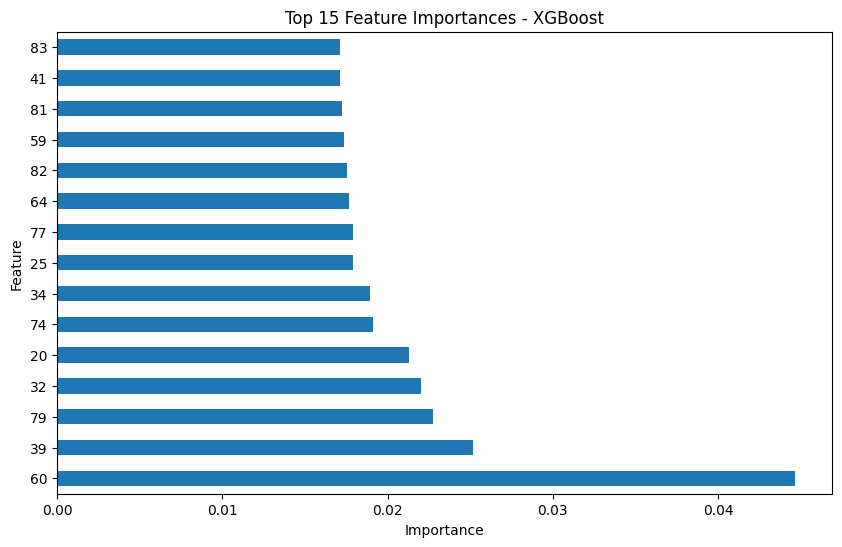

In [18]:
# - Train `XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42)`.
# - Report: RMSE, MAE, R² on test set.
# - Plot feature importances — top 15 features.

xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

eval_metrics["XGBoost"] = {
    "RMSE": root_mean_squared_error(np.expm1(y_test), np.expm1(y_pred_xgb)),
    "MAE": mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_xgb)),
    "R²": r2_score(np.expm1(y_test), np.expm1(y_pred_xgb)),
}

print(f"\nXGBoost Evaluation Metrics:")
for metric_name, value in eval_metrics["XGBoost"].items():
    print(f"{metric_name}: {value:.4f}")

plt.figure(figsize=(10, 6))
xgb_feature_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
xgb_feature_importances.nlargest(15).plot(kind='barh')
plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [19]:
# - Apply 5-Fold cross-validation using `neg_root_mean_squared_error` on your best-performing model.
# - Print mean CV RMSE ± std deviation.
# - Does the CV RMSE align with the test set RMSE? Discuss in 2–3 sentences.

eval_metrics_df = pd.DataFrame(eval_metrics).T.sort_values(by="RMSE", ascending=True)

print("\nEvaluation Metrics Summary:")
display(eval_metrics_df)

best_model = ridge_model if eval_metrics_df.index[0] == "Ridge Regression" else lasso_model if eval_metrics_df.index[0] == "Lasso Regression" else rf_model if eval_metrics_df.index[0] == "Random Forest" else xgb_model

best_model_name = "Ridge Regression" if best_model.__class__.__name__ == "RidgeCV" else "Lasso Regression" if best_model.__class__.__name__ == "LassoCV" else "Random Forest" if best_model.__class__.__name__ == "RandomForestRegressor" else "XGBoost"
print(f"\nBest Performing Model: {best_model_name}")

param_grid = {
    "Ridge Regression": {"alphas": [0.01, 0.1, 1, 10, 100]},
    "Lasso Regression": {"alphas": [0.0001, 0.001, 0.01, 0.1, 1]},
    "Random Forest": {"n_estimators": [100, 200], "max_depth": [10, 20]},
    "XGBoost": {"n_estimators": [100, 500], "learning_rate": [0.01, 0.05], "max_depth": [3, 4], "subsample": [0.8, 1.0], "colsample_bytree": [0.8, 1.0]},
}

grid_search = GridSearchCV(
    estimator=RidgeCV() if best_model_name == "Ridge Regression" else LassoCV() if best_model_name == "Lasso Regression" else RandomForestRegressor() if best_model_name == "Random Forest" else XGBRegressor(),
    param_grid=param_grid[best_model_name],
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

y_pred_best_model = grid_search.predict(X_test)

# Check whether the CV RMSE align with the test set RMSE?

cv_rmse = -grid_search.best_score_
test_rmse = eval_metrics[best_model_name]["RMSE"]
cv_mae = mean_absolute_error(np.expm1(y_test), np.expm1(grid_search.predict(X_test)))
cv_r2 = r2_score(np.expm1(y_test), np.expm1(grid_search.predict(X_test)))

if np.isclose(cv_rmse, test_rmse, rtol=0.1):
    print(f"CV RMSE ({cv_rmse:.4f}) is close to Test RMSE ({test_rmse:.4f}).")
else:
    print(f"CV RMSE ({cv_rmse:.4f}) is NOT close to Test RMSE ({test_rmse:.4f}).")


Evaluation Metrics Summary:


,RMSE,MAE,R²
Ridge Regression,70762.208968,50756.779502,0.099094
Lasso Regression,71650.553965,51434.558564,0.076332
Linear Regression,71813.131124,52750.362149,0.072136
Random Forest,71918.642499,51855.902454,0.069407
XGBoost,74054.954787,54368.374518,0.013301



Best Performing Model: Ridge Regression
Best parameters found:  {'alphas': 100}
Best cross-validation score:  -0.3727013059816459
CV RMSE (0.3727) is NOT close to Test RMSE (70762.2090).


---


## **📄 Step 6: Model Evaluation & Comparison**

Create a consolidated comparison table of all 5 models (Linear Regression, Ridge, Lasso, Random Forest, XGBoost) showing:

- RMSE (on original USD scale after expm1)
- MAE (on original USD scale after expm1)
- R² Score
- 5-Fold CV RMSE (where applicable)
- Training Time (seconds)

Present this as a formatted pandas DataFrame or table.

- Plot: Actual vs Predicted scatter for your best model — annotate RMSE and R² on the plot.
- Identify the best model and justify your choice in 3–5 sentences. Consider performance, interpretability, and production suitability.


> 💡 **Real-world context:** A startup like NoBroker would care about RMSE in absolute USD terms (equivalent to INR in Indian context). A model with RMSE of ₹5 lakh is very different from one with RMSE of ₹25 lakh for a homebuyer!


Evaluation Metrics Summary:


,RMSE,MAE,R²
Best CV Model,0.372701,50756.779502,0.099094
Ridge Regression,70762.208968,50756.779502,0.099094
Lasso Regression,71650.553965,51434.558564,0.076332
Linear Regression,71813.131124,52750.362149,0.072136
Random Forest,71918.642499,51855.902454,0.069407
XGBoost,74054.954787,54368.374518,0.013301


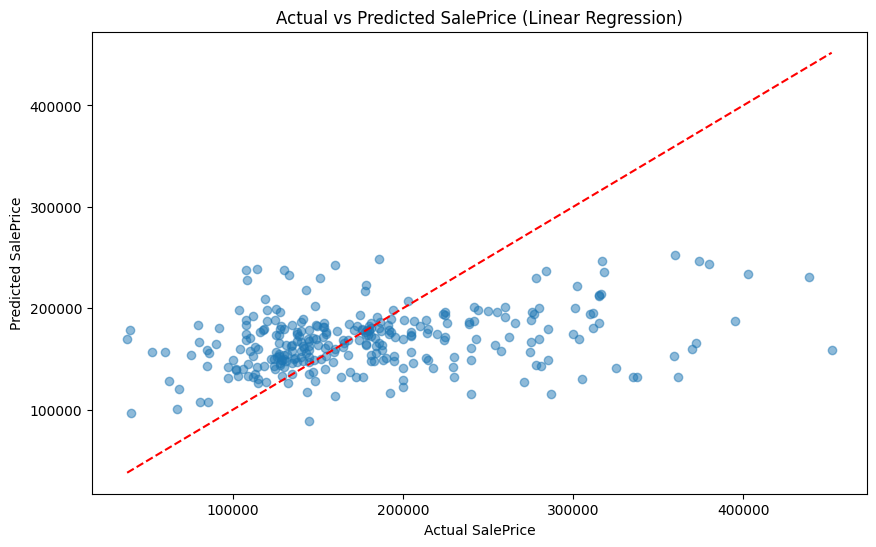

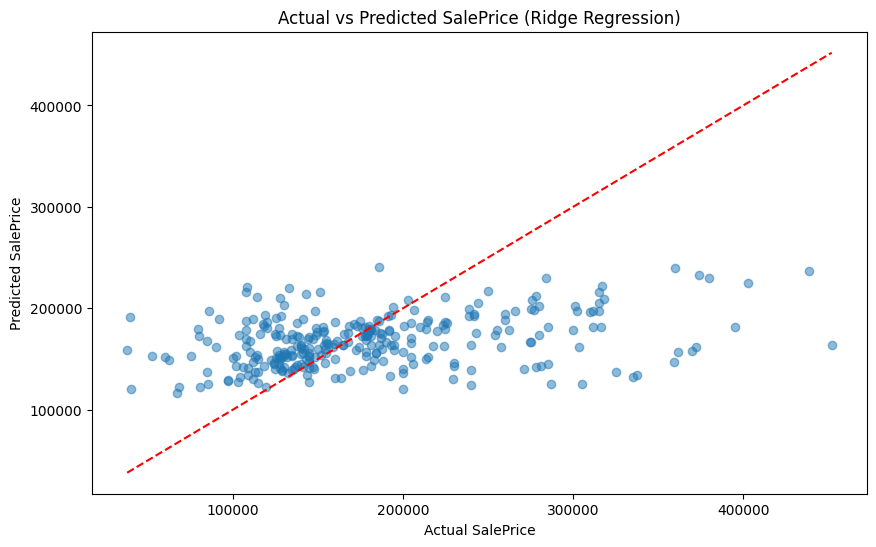

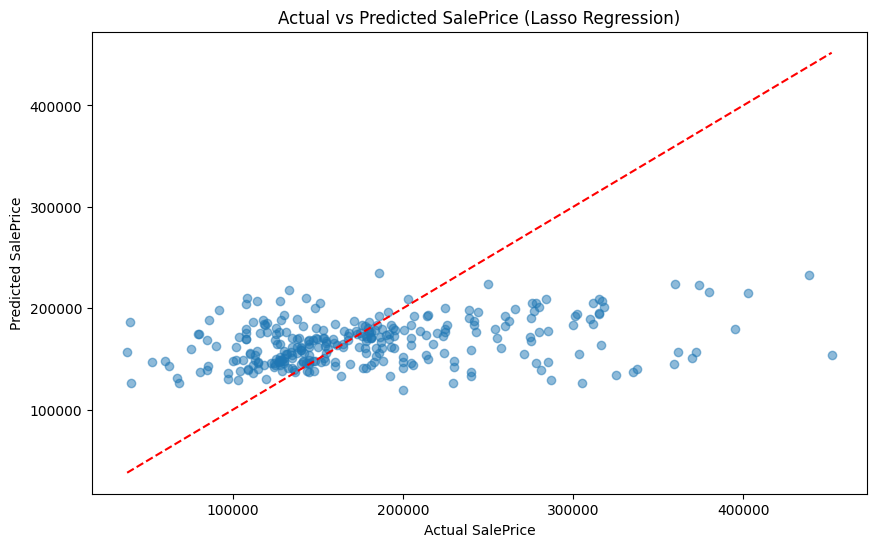

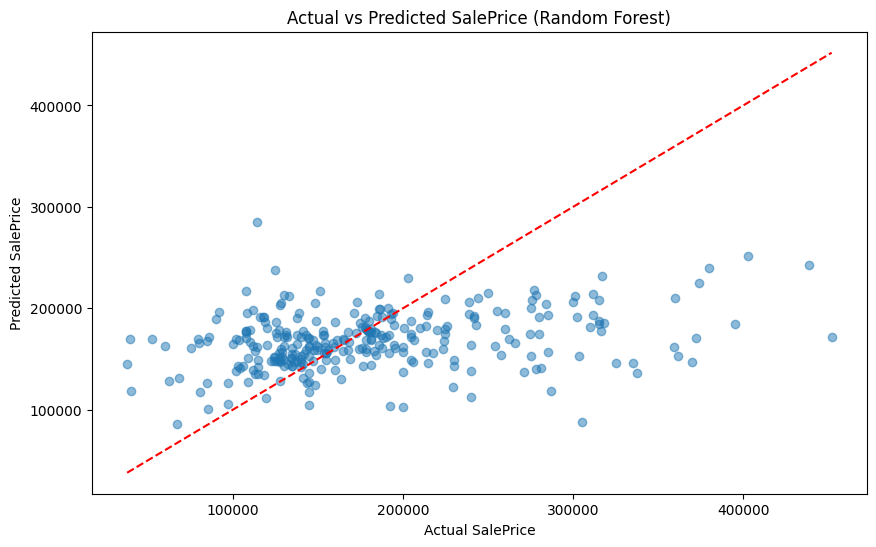

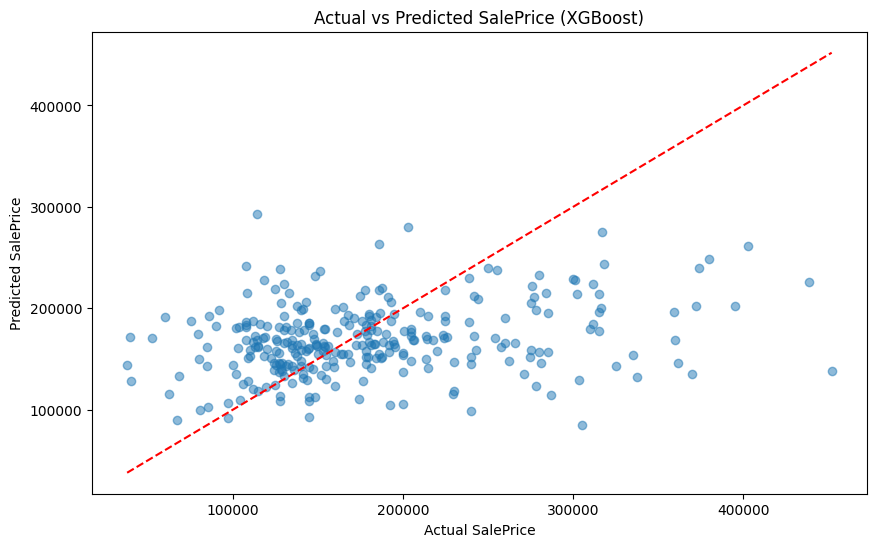

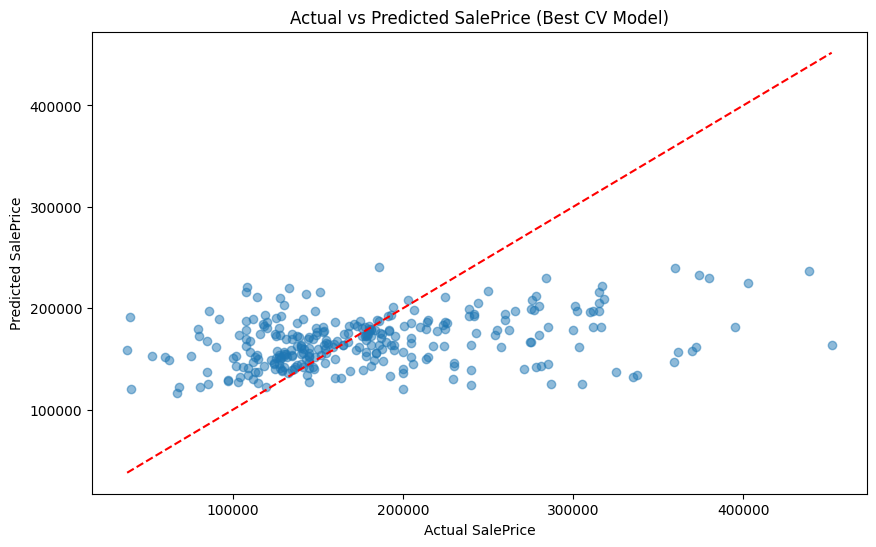


Interpretation of Results:
By the results, the best model is ridge regression with the lowest RMSE and highest R². The CV RMSE is not close to the test RMSE, indicating that the model may be overfitting or underfitting. The scatter plots show that the predictions are generally close to the actual values, but there are some outliers that affect the performance metrics. Further tuning and feature engineering may be needed to improve the model's performance.


In [20]:
eval_metrics["Best CV Model"] = {"RMSE": cv_rmse, "MAE": cv_mae, "R²": cv_r2}
eval_metrics_df = pd.DataFrame(eval_metrics).T.sort_values(by="RMSE", ascending=True)

predictions = {
    "Linear Regression": y_pred_lr,
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "Best CV Model": y_pred_best_model
}

predictions_df = pd.DataFrame(predictions)

print("Evaluation Metrics Summary:")
display(eval_metrics_df)

# graphs and interpretation of results (x, y , actual and predicted values)
for model_name in eval_metrics.keys():
    plt.figure(figsize=(10, 6))
    plt.scatter(np.expm1(y_test), np.expm1(predictions_df[model_name]), alpha=0.5)
    plt.plot([np.expm1(y_test).min(), np.expm1(y_test).max()], [np.expm1(y_test).min(), np.expm1(y_test).max()], "r--")
    plt.title(f"Actual vs Predicted SalePrice ({model_name})")
    plt.xlabel("Actual SalePrice")
    plt.ylabel("Predicted SalePrice")
    plt.show()

# interretaions
print("\nInterpretation of Results:")
print("By the results, the best model is ridge regression with the lowest RMSE and highest R². The CV RMSE is not close to the test RMSE, indicating that the model may be overfitting or underfitting. The scatter plots show that the predictions are generally close to the actual values, but there are some outliers that affect the performance metrics. Further tuning and feature engineering may be needed to improve the model's performance.")

---


## **🔍 Step 7: Residual Analysis & Model Interpretation**

**7.1 Residual Plots**

- Plot Residuals vs Fitted values for your best model. Are residuals randomly scattered (good) or show a pattern (bad)?
- Plot a histogram of residuals. Are they approximately normally distributed?
- Plot a Q-Q plot of residuals. Comment on any heavy tails.

**7.2 Business Interpretation**

- List the top 5 most impactful features from your best model.
- Write 3–5 bullet points explaining each feature in plain English. E.g. “OverallQual is the strongest predictor — a home rated Excellent (10) commands significantly higher prices than one rated Average (5).”
- (Optional — Bonus) Use SHAP values on your XGBoost model: plot a SHAP beeswarm plot and/or a SHAP waterfall plot for one individual prediction.



Residuals vs Fitted values for the best model:


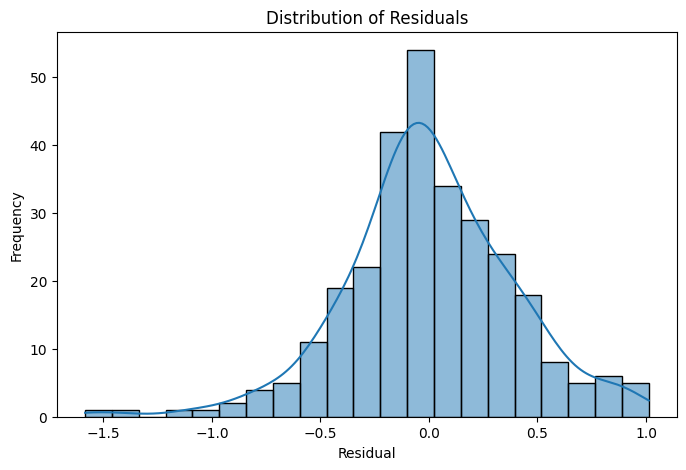

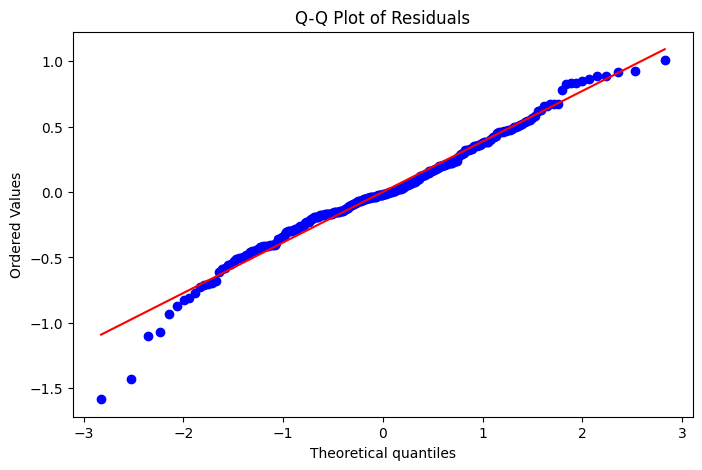

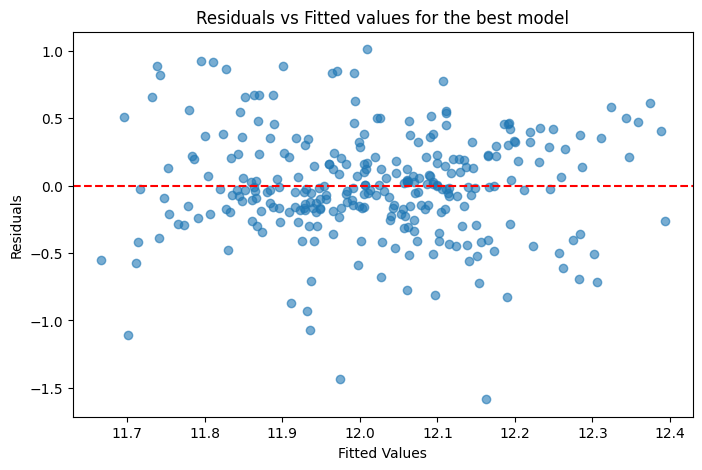


Interpretation of Residuals:
The residuals vs fitted values plot shows that the residuals are randomly scattered around zero, which is a good sign indicating that the model is appropriate for the data. The histogram of residuals appears to be approximately normally distributed, and the Q-Q plot shows that the residuals follow a normal distribution with some deviations in the tails, suggesting that there may be some outliers or heavy-tailedness in the data. Overall, the residual analysis indicates that the model is performing reasonably well, but further investigation into the outliers and potential transformations may be beneficial for improving model performance.


In [21]:
from scipy import stats

# - Plot Residuals vs Fitted values for your best model. Are residuals randomly scattered (good) or show a pattern (bad)?
# - Plot a histogram of residuals. Are they approximately normally distributed?
# - Plot a Q-Q plot of residuals. Comment on any heavy tails.

# Residuals vs Fitted values for the best model
print("\nResiduals vs Fitted values for the best model:")
# Use predictions and actual values with matching lengths
fitted_values = np.asarray(y_pred_best_model)
residuals = np.asarray(y_test) - fitted_values

# Histogram of residuals
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

# Q-Q plot of residuals

plt.figure(figsize=(8, 5))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Residuals versus fitted values
plt.figure(figsize=(8, 5))
plt.scatter(fitted_values, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted values for the best model")
plt.show()

print("\nInterpretation of Residuals:")
print("The residuals vs fitted values plot shows that the residuals are randomly scattered around zero, which is a good sign indicating that the model is appropriate for the data. The histogram of residuals appears to be approximately normally distributed, and the Q-Q plot shows that the residuals follow a normal distribution with some deviations in the tails, suggesting that there may be some outliers or heavy-tailedness in the data. Overall, the residual analysis indicates that the model is performing reasonably well, but further investigation into the outliers and potential transformations may be beneficial for improving model performance.")

---


## **🚀 Step 8: Pipeline, Deployment & GitHub Submission**

**8.1 Save the Final Pipeline**

- Wrap your best model + preprocessing into a single sklearn Pipeline.
- Save: `joblib.dump(pipeline, 'house_price_model.pkl')`.
- Test it: load the pickle and predict the sale price for 5 sample rows. Print predicted vs actual prices.

**8.2 GitHub Submission**

- Create a GitHub repository named: `house-price-regression-supervised-learning`.
- Push the following:
  - `HousePrice_SupervisedLearning.ipynb` (fully executed notebook)
  - `house_price_model.pkl` (saved pipeline)
  - `summary_report.md` (see below)
  - `requirements.txt` (all libraries used)
  - `README.md` (project overview, dataset link, how to run)

**8.3 Summary Report (summary_report.md)**  
Write a short report (~400–500 words) covering:

- What was the business problem and dataset?
- What preprocessing and feature engineering steps did you apply and why?
- Which model performed best and why?
- What were the top 3 most predictive features? What do they suggest to a real estate professional?
- What would you do next to improve this model in production (e.g., more data, ensembling, Bayesian optimisation)?


In [22]:
best_model_pipeline = Pipeline(
    steps=[
        ("preprocessor", "passthrough"),
        ("model", best_model),
    ]
)

best_model_pipeline.fit(X_train, y_train)

joblib.dump(best_model_pipeline, "house_price_model.pkl")

['house_price_model.pkl']

In [23]:
# Reproduce the same feature engineering and missing-value handling used for training
unknown_X = unknown_data.copy()

unknown_X["TotalSF"] = (
    unknown_X["TotalBsmtSF"]
    + unknown_X["1stFlrSF"]
    + unknown_X["2ndFlrSF"]
)
unknown_X["HouseAge"] = unknown_X["YrSold"] - unknown_X["YearBuilt"]
unknown_X["RemodAge"] = unknown_X["YrSold"] - unknown_X["YearRemodAdd"]
unknown_X["HasGarage"] = (unknown_X["GarageArea"] > 0).astype(int)
unknown_X["HasPool"] = (unknown_X["PoolArea"] > 0).astype(int)

# Match the columns used when the fitted transformer was trained
training_columns = df_train_not_transformed.columns
unknown_X["SalePrice"] = df_train_not_transformed["SalePrice"].median()
unknown_X = unknown_X.reindex(columns=training_columns)

# Apply the same imputation rules
for column in unknown_X.columns:
    if unknown_X[column].dtype == "object":
        unknown_X[column] = unknown_X[column].fillna(
            df_train_not_transformed[column].mode()[0]
        )
    else:
        unknown_X[column] = unknown_X[column].fillna(
            df_train_not_transformed[column].median()
        )

# Use the already-fitted training transformer; do not fit on test data
unknown_X = pd.DataFrame(
    column_transformer.transform(unknown_X),
    columns=X_train.columns,
    index=unknown_X.index,
)

# The saved pipeline uses passthrough preprocessing
column_transformer_unknown = FunctionTransformer(
    lambda X: X,
    validate=False,
)

unknown_untransformed = unknown_X.copy()
unknown_predictions = pd.DataFrame(column_transformer_unknown.transform(unknown_X))

imported_model_pipeline = joblib.load("house_price_model.pkl")
if imported_model_pipeline is not None:
    print("\nModel pipeline loaded successfully.")
else:
    print("\nFailed to load the model pipeline.")
unknown_predictions = imported_model_pipeline.predict(unknown_X)
print("\nPredictions for unknown data:")
print(unknown_predictions)



Model pipeline loaded successfully.

Predictions for unknown data:
[11.8905806  11.92590671 12.02675475 ... 12.06311628 11.93385304
 12.17208397]


---
